## Preamble

In [ ]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import pygmt
from pyrolite.util.time import Timescale
ts = Timescale()
import os
import rioxarray as rio
from scipy.ndimage import gaussian_filter
import scipy.stats as stats
from scipy.stats import sem 
import shutil
import skimage
import sys
import xarray as xr
import xesmf as xe

from Code import pbdb_dataset, paleoRotator, climateScenario, getBiomodSDMs, present_day_distribution
from importlib import reload
reload(pbdb_dataset)
reload(paleoRotator)
reload(climateScenario)
reload(getBiomodSDMs)
reload(present_day_distribution)

continental_polygons = 'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/StaticGeometries/ContinentalPolygons/Global_EarthByte_GPlates_PresentDay_ContinentalPolygons.shp'
ZAH22_rotationFile = f'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/CombinedRotations.rot'
ZAH22_static_polygon_file = f'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/StaticGeometries/StaticPolygons/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.shp'
ZAH22Recon = paleoRotator.PaleoRotator(ZAH22_rotationFile, ZAH22_static_polygon_file)

scotese_rotationFile = '/Applications/GPlates_2.5.0/GeoData/FeatureCollections/AltPlateReconstructions/Scotese_PALEOMAP_GlobalPlateModel/PALEOMAP_PlateModel.rot'
scotese_static_polygon_file = "/Applications/GPlates_2.5.0/GeoData/FeatureCollections/AltPlateReconstructions/Scotese_PALEOMAP_GlobalPlateModel/PALEOMAP_TerranePolygons.gpmlz"
scoteseRecon = paleoRotator.PaleoRotator(scotese_rotationFile, scotese_static_polygon_file)

ZAH22SimulationDirectory = 'data/climate_simulations/ZAH22_paleomag'
scoteseSimulationDirectory = 'data/climate_simulations/scotese'
co2s = [sim.split('_')[-1] for sim in os.listdir(ZAH22SimulationDirectory) if not os.path.isfile(os.path.join(ZAH22SimulationDirectory, sim))]
co2s = sorted([c for c in co2s if c.isdigit()], key=int) + [c for c in co2s if not c.isdigit()]
modelAges = np.arange(0,260,10)

ZAH22Scenario = climateScenario.ClimateScenario(ZAH22SimulationDirectory, co2s, modelAges)
scoteseScenario = climateScenario.ClimateScenario(scoteseSimulationDirectory, co2s, modelAges)

# These should be the names of any folders that differentiate the different scenario
ZAH22Scenario.outputName = 'proj_ZAH22_paleomag'
scoteseScenario.outputName = 'proj_scotese'

# ZAH22TopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_ZAH22/topos_filled_PaleomagRef"
# scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ZAH22TopoPath = f"data/paleogeography/topos_filled_PaleomagRef"
scoteseTopoPath = f"data/paleogeography/Scotese_1deg_renamed"
ZAH22Scenario.topoPath = ZAH22TopoPath
scoteseScenario.topoPath = scoteseTopoPath

fosterCO2_file = 'data/fosterCO2.txt'
fosterCO2_data = pd.read_csv(fosterCO2_file, delim_whitespace=True, comment='#', names=['Age', 'CO2'])
fosterCO2_data = fosterCO2_data.set_index('Age')

merdith_file = 'data/paleotemperature_datasets/Merdith2024/ALL_ON_r=1000_2025Feb13.obj'
pySCION_classes_path = 'data/paleotemperature_datasets/Merdith2024/pySCION_classes.py'
scotese_file = 'data/paleotemperature_datasets/scotese2021_paleotemps/Part 4. Phanerozoic_Paleotemperature_Summaryv4.xlsx'
phanDA_file = 'data/paleotemperature_datasets/PhanDA_GMSTandCO2_percentiles.csv'
grossmann_file = 'data/paleotemperature_datasets/paleotemperatures_Grossman_Joachimski_2022/41598_2022_11493_MOESM7_ESM.xlsx'
# phanDA_SST_file = 'data/paleotemperature_datasets/PhanDA_tropicalSST_digitised.csv'
phanDA_SST_file = 'data/paleotemperature_datasets/PhanDA_TropicalSST_30S30N.xlsx'
song_file = 'data/paleotemperature_datasets/Song_et_al_2019.xlsx'

pbdb_data_path = 'data/fossils/scleractinia_pbdb.csv' # Do the dataset from Danijela so we can filter for zooxanthellate corals
pbdbDataset = pbdb_dataset.PBDB_dataset(pbdb_data_path).basic_df()
basicPBDBData = pbdb_dataset.basicLocalityData(pbdbDataset)
PBDB_df = basicPBDBData.reconstruct_points(ZAH22Recon, columnPrefix='ZAH22_', anchor_plate_id=701701, gpmlName='data/fossils/gpmls/ZAH22_pbdb.gpml')
PBDB_df = basicPBDBData.reconstruct_points(scoteseRecon, columnPrefix='scotese_', anchor_plate_id=0, gpmlName='data/fossils/gpmls/PALEOMAP_pbdb.gpml')
PBDB_df = basicPBDBData.removeMidOceanpoints(continental_polygons)

# PARED dataset as an alternative to the PBDB
pared_data_path = 'data/fossils/reefs_pared.csv'
pared_dataset = pbdb_dataset.paredDataset(pared_data_path).basic_df()
basicParedData = pbdb_dataset.basicLocalityData(pared_dataset)
pared_DF = basicParedData.reconstruct_points(ZAH22Recon, columnPrefix='ZAH22_', anchor_plate_id=701701, gpmlName='data/fossils/gpmls/ZAH22_pared.gpml')
pared_DF = basicParedData.reconstruct_points(scoteseRecon, columnPrefix='scotese_', anchor_plate_id=0, gpmlName='data/fossils/gpmls/PALEOMAP_pared.gpml')
pared_DF = basicParedData.removeMidOceanpoints(continental_polygons)

# Choose which dataset to use
basicParedData = basicPBDBData # This is a lazy solution to using the pbdb data without changing all the variables
paredDF = PBDB_df
# If you want to use the PARED data, uncomment these lines and comment the above two lines
# Also, if you want to use the pbdb data that doesn't filter out non-reef stuff then you need to edit the pbdb_dataset.py file
# basicParedData = basicParedData
# paredDF = pared_DF

# Identifiers for what fossil data was used. To go in relevant figure names
# fossilID = 'pared'
# fossilID = 'pbdb_zooOnly
fossilID = 'pbdb_zoo_and_reef'

mm = 1/25.4  # mm in inches

plt.rcParams['font.size']=6.5
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['xtick.labelsize'] = 6.5
plt.rcParams['ytick.labelsize'] = 6.5
# plt.rcParams['font.sans-serif'] = ['Helvetica']
# pyGMT config variables
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP='ddd:mm:ssF')
pygmt.config(MAP_FRAME_PEN='thin')
pygmt.config(FONT='5.5p,Helvetica,black')
pygmt.config(FONT_TAG='9.3p,Helvetica,black')
pygmt.config(FONT_LABEL='6.5p,Helvetica,black')
pygmt.config(FONT_ANNOT_PRIMARY="6.5p")
pygmt.config(FONT_ANNOT_SECONDARY="5.5p")
pygmt.config(FONT_HEADING='7p,Helvetica,black')
pygmt.config(FONT_TITLE='7p,Helvetica,black') #The title above subplots
pygmt.config(PROJ_LENGTH_UNIT='cm')
pygmt.config(MAP_HEADING_OFFSET='-0.2c') # Dist between plots and main heading
pygmt.config(MAP_GRID_PEN_PRIMARY='0.6p,grey')
pygmt.config(COLOR_NAN="grey")

# pyGMT mapping defaults
# proj="W0/15c" # Mollweide
proj="Q16" # Cylindrical equidistant projection
region='d' # d = Global region
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
w="1.5p,black" # default pen settings for drawing plate boundaries etc
bar="JBC+o0/-1.5" # Default position and width for the colorbar

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_72595/2348903116.py:58: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fosterCO2_data = pd.read_csv(fosterCO2_file, delim_whitespace=True, comment='#', names=['Age', 'CO2'])
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/Code/pbdb_dataset.py:62: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  # self.df = self.df[['occurrence_no', 'max_ma', 'min_ma', 'lng', 'lat']]
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/Code/pbdb_dataset.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

PBDB data: Number of unique occurrence_no before filtering and cleaning: 32194
Number of unique occurrence_no after selecting only zooxanthellate corals: 25551
Number of unique occurrence_no after selecting only reef and zooxanthellate sites: 20005
Number of unique occurrence_no after removing duplicates: 1758
Number of unique occurrence_no after removing missing lat/lng: 1758
Setting valid time for point 0: maxAge=246.7, minAge=0.0
Setting valid time for point 1: maxAge=246.7, minAge=0.0
Setting valid time for point 2: maxAge=246.7, minAge=0.0
Setting valid time for point 3: maxAge=244.99, minAge=0.0
Setting valid time for point 4: maxAge=244.99, minAge=0.0
Setting valid time for point 5: maxAge=244.99, minAge=0.0
Setting valid time for point 6: maxAge=244.99, minAge=0.0
Setting valid time for point 7: maxAge=244.99, minAge=0.0
Setting valid time for point 8: maxAge=244.99, minAge=0.0
Setting valid time for point 9: maxAge=244.99, minAge=0.0
Setting valid time for point 10: maxAge=244

/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/Code/pbdb_dataset.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['latit'] = df['latit'].round(2)
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/Code/pbdb_dataset.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return df.rename(columns={'longit':'lon', 'latit':'lat', 'mid':'age', 'nearest10':'age10', 'min_ma':'minAge', 'max_ma':'maxAge', 

Reconstructing point 0 at age 240.0 with anchor plate ID 701701
Plate ID: 602
Valid time: (247.2, 0.0)
Original geometry (lat, lon): (23.77, 106.88)
Reconstruction time: 240.0
Reconstructed geometry (lat, lon): (18.53758370849228, 103.38457242195626)
Reconstructed points: [<pygplates.pygplates.ReconstructedFeatureGeometry object at 0x1debbc820>]


Reconstructing point 1 at age 240.0 with anchor plate ID 701701
Plate ID: 349
Valid time: (247.2, 0.0)
Original geometry (lat, lon): (40.73, 22.92)
Reconstruction time: 240.0
Reconstructed geometry (lat, lon): (18.969669124065277, 35.87704815579257)
Reconstructed points: [<pygplates.pygplates.ReconstructedFeatureGeometry object at 0x1debbc820>]


Reconstructing point 2 at age 240.0 with anchor plate ID 701701
Plate ID: 302
Valid time: (247.2, 0.0)
Original geometry (lat, lon): (50.57, 18.08)
Reconstruction time: 240.0
Reconstructed geometry (lat, lon): (27.70452820320258, 32.44725221058086)
Reconstructed points: [<pygplates.pygplates.Reconstr

## Get Geological Stages

In [241]:
# Geological timescale date

# Only get the eras where start time is more than 252
eras = ts.Eras[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
epochs = ts.Epochs[ts.Epochs['Start'] < 252].copy().reset_index(drop=True)
# Add a new column with names shortened to the first 3 letters
epochs['ShortName'] = ''
for i, row in epochs.iterrows():
    if epochs.loc[i, 'Start'] - epochs.loc[i, 'End'] < 10:
        epochs['ShortName'].loc[i] = ''
    elif len(epochs.loc[i, 'Name'].split(' ')) > 1:
        word1 = epochs.loc[i, 'Name'].split(' ')[0]
        word2 = epochs.loc[i, 'Name'].split(' ')[1]
        epochs['ShortName'].loc[i] = f"{word1[0]}. {word2[:3]}"
    else:
        epochs['ShortName'].loc[i] = epochs.loc[i, 'Name'][:3]


geologicalAges = ts.Ages[ts.Ages['Start'] < 550].copy().reset_index(drop=True)
# Merge ages that are in the same epoch and last less than 5 million years
mergedAges = pd.DataFrame(columns=['Name', 'Start', 'End', 'Period', 'Color'])
for period, group in geologicalAges.groupby('Period'):
    for i in range(len(group) - 1):
        try:
            print(np.abs(group['Start'].iloc[i + 1]) - np.abs(group['End'].iloc[i]))
        except IndexError:
            print("IndexError: Skipping to next iteration")
            break
        if np.abs(group['Start'].iloc[i + 1]) - np.abs(group['End'].iloc[i]) < 10:

            print(f"Merging ages {group['Name'].iloc[i]} and {group['Name'].iloc[i + 1]}")
            mergedAges = pd.concat([mergedAges, pd.DataFrame({
                'Name': [group['Name'].iloc[i] + ' - ' + group['Name'].iloc[i + 1]],
                'Start': [group['Start'].iloc[i+1]],
                'End': [group['End'].iloc[i]],
                'Period': [group['Period'].iloc[i]],
                'Color': [group['Color'].iloc[i]]
            })], ignore_index=True)
            group = group.drop(index=group.index[i + 1])
        else:
            mergedAges = pd.concat([mergedAges, pd.DataFrame({
                'Name': [group['Name'].iloc[i]],
                'Start': [group['Start'].iloc[i]],
                'End': [group['End'].iloc[i]],
                'Period': [group['Period'].iloc[i]],
                'Color': [group['Color'].iloc[i]]
            })], ignore_index=True)


mergedAges['MeanAge'] = round((mergedAges['Start'] + mergedAges['End']) / 2, 2)
mergedAges = mergedAges.sort_values(by='End').reset_index(drop=True)

geoAges = mergedAges['Start'].tolist()
mergedAges.head(60)

8.600000000000023
Merging ages Furongian Stage 10 and Jiangshanian
6.5
Merging ages Paibian and Guzhangian
8.5
Merging ages Drumian and Wuliuan
12.0
15.0
17.799999999999955
IndexError: Skipping to next iteration
8.100000000000023
Merging ages Gzhelian and Kasimovian
16.19999999999999
15.699999999999989
23.5
28.0
IndexError: Skipping to next iteration
17.599999999999994
14.200000000000003
6.200000000000003
Merging ages Santonian and Coniacian
10.700000000000003
19.099999999999994
20.900000000000006
16.400000000000006
11.199999999999989
10.400000000000006
12.400000000000006
IndexError: Skipping to next iteration
23.80000000000001
15.5
10.600000000000023
19.900000000000034
17.5
11.599999999999966
9.800000000000011
Merging ages Tithonian and Kimmeridgian
10.5
6.699999999999989
Merging ages Callovian and Bathonian
6.5
Merging ages Bajocian and Aalenian
18.80000000000001
15.300000000000011
8.5
Merging ages Sinemurian and Hettangian
IndexError: Skipping to next iteration
2.753
Merging ages Pi

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_72595/1758706078.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epochs['ShortName'].loc[i] = ''
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_72595/1758706078.py:1

,Name,Start,End,Period,Color,MeanAge
0,Meghalayan - Northgrippian,0.0082,0.0000,Quaternary,"(0.996078431372549, 0.9490196078431372, 0.9254...",0.00
1,Greenlandian - Upper Pleistocene,0.1290,0.0082,Quaternary,"(0.996078431372549, 0.9490196078431372, 0.9254...",0.07
2,Chibanian - Calabrian,1.8000,0.1290,Quaternary,None,0.96
3,Piacenzian - Zanclean,5.3330,2.5800,Neogene,"(1.0, 1.0, 0.7490196078431373, 1.0)",3.96
4,Messinian - Tortonian,11.6300,5.3330,Neogene,"(1.0, 1.0, 0.45098039215686275, 1.0)",8.48
5,Serravallian - Langhian,15.9700,11.6300,Neogene,"(1.0, 1.0, 0.34901960784313724, 1.0)",13.80
6,Burdigalian - Aquitanian,23.0300,15.9700,Neogene,"(1.0, 1.0, 0.2549019607843137, 1.0)",19.50
7,Chattian,27.8200,23.0300,Paleogene,"(0.996078431372549, 0.9019607843137255, 0.6666...",25.42
8,Rupelian - Priabonian,37.7100,27.8200,Paleogene,"(0.996078431372549, 0.8509803921568627, 0.6039...",32.76
9,Bartonian,41.2000,37.7100,Paleogene,"(0.9921568627450981, 0.7529411764705882, 0.568...",39.46


## Function library

### clip2shelves function

In [242]:
def clip2shelves(age, ensemblePath, topoPath, dontClip=False, fuzzyLogic=False):
    """
    Clip the ensemble data to the shelves based on the topography grid.
    """
    if fuzzyLogic:
        ensembleDS = xr.open_dataset(ensemblePath)
        dataEM = ensembleDS.rename({'longitude': 'lon', 'latitude': 'lat'})
        dataEM['wmean'] = dataEM['tempProb']

        if dontClip:
            dataEM['e_mean_shelf'] = dataEM['wmean']
            return dataEM

    else:
        ensembleDS = rio.open_rasterio(ensemblePath, masked=True)

        # Convert ensemble to netcdf
        dataType = ['e_mean','cv','e_median','ca','wmean','ciInf', 'ciSup']

        dataName = ['Mean', 'Coefficient of variation', 'Median', 
                    'Committee averaging score', 'Weighted mean', 
                    'Confidence interval (lower)', 'Confidence interval (upper)']

        k = -1
        for k in range(len(dataType)):
            nda = xr.DataArray(
                            # ensembleDS.isel(band=k).band_data.values,
                            ensembleDS.isel(band=k).values,
                            dims=["lat", "lon"],
                            coords={"lat": ensembleDS.y.values, "lon": ensembleDS.x.values},
                        )

            if k == 0:
                dataEM = nda.to_dataset(name=dataType[k])

            tmp = nda.fillna(0).values
            dataEM[dataType[k]] = (('lat', 'lon'), gaussian_filter(tmp,1))
        if dontClip:
            dataEM['e_mean_shelf'] = dataEM['wmean']
            return dataEM

    # Regrid to 721 x 361
    lon_target = xr.DataArray(np.linspace(-179.25, 179.75, 720), dims='lon')
    lat_target = xr.DataArray(np.linspace(-89.75, 89.75, 360), dims='lat')
    target_grid = xr.Dataset({'lon': lon_target, 'lat': lat_target})

    # Define the regridder
    regridder = xe.Regridder(dataEM, target_grid, method='nearest_s2d')

    # Perform the regridding
    ensembleRegrid = regridder(dataEM)

    # Now bring in the topo grid with shelf data
    tmpGrid = f'tmp_topo_{age}'
    if os.path.exists(tmpGrid):
        os.remove(tmpGrid)

    shutil.copy(topoPath, os.path.join(os.getcwd(), tmpGrid))

    # Open the netCDF file
    topoDS = xr.open_dataset(tmpGrid)
    topoDS = pygmt.grdsample(grid=topoDS['z'],registration='p')

    # # Convert to 0-360
    # topoDS['lon'] = topoDS['lon'].where(topoDS['lon'] >= 0, topoDS['lon'] + 360)
    # topoDS = topoDS.sortby('lon')

    # Define the regridder
    regridder = xe.Regridder(topoDS, target_grid, method='nearest_s2d')
    topoDS = regridder(topoDS)

    ensembleRegrid['topo'] = topoDS

    # Extract the shelves
    grid_data = ensembleRegrid['topo']


    # Make every value an integer
    grid_data = grid_data.astype(int)


    # Create a mask for shallow shelf values
    # shelf = (grid_data >= -1500) & (grid_data < 1)
    # shelf = (grid_data >= -1200) #& (grid_data < 1)
    shelf = (grid_data >= -2000)

    # Set non-shelf values to 0
    grid_data = grid_data.where(shelf, 0)
    grid_data = grid_data.where(~shelf, 1)

    ensembleRegrid['shelf'] = grid_data
    # ensembleRegrid['shelf'].plot()

    ensembleRegrid['e_mean_shelf'] = ensembleRegrid['wmean'].where(ensembleRegrid.shelf == 1)
    # ensembleRegrid['e_mean_shelf'].plot()]

    # Remove tmp files
    for file in os.listdir(os.getcwd()):
        # print(file)
        if file.startswith('tmp'):
            os.remove(file)    

    return ensembleRegrid


### get_contours function

In [243]:
def get_contours(ds, lons, lats, var):
    """
    Get contours from a dataset for given longitudes and latitudes and returns contours that trace around the vertices of the grid cells (rather than the mid points)

    This function uses the skimage.measure.find_contours function to find contours in the data.
    """
    # Check if the variable exists in the dataset
    if var not in ds:
        raise ValueError(f"Variable '{var}' not found in the dataset.")

    ## Create a new boolean DataArray with the same dimensions of ds but showing whether each pixel does or does not contain a reef
    #Initialize the 'isReef' variable with zeros in the same dimensions as the dataset
    new_da = xr.zeros_like(ds[var])

    # Convert the paleoreef points to a DataArray since that's easiest to work with the sel function
    points_ds = xr.Dataset({"longitude": ("points", lons), "latitude": ("points", lats),})

    # Also make sure lons are 0-360
    points_ds["longitude"] = points_ds["longitude"] % 360

    # Find the nearest grid cells for all points
    nearest_cells = new_da.sel(longitude=points_ds["longitude"], latitude=points_ds["latitude"], method="nearest")
    
    # Update the 'isReef' variable for all nearest cells
    new_da.loc[{"longitude": nearest_cells["longitude"], "latitude": nearest_cells["latitude"]}] = 1

    contours = skimage.measure.find_contours(new_da.values, level=0.5)

    contour_index = 0
    for contour in contours:
        # Insert a new contour point into the corner of each cell
        i_skip = False
        i = 0
        max_range = len(contour)
        while i < max_range: # Loop over points in the contour
            if i_skip:
                i_skip = False
                continue
            
            y, x = contour[i]
            yp,xp = contour[i-1]
            if y != yp and x != xp:
                if y < yp and x < xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y < yp and x > xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x > xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x < xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
            i += 1
        
        # This bit moves the mini 'steps' that persist for more complex contours
        for i in range(len(contour)):
            y, x = contour[i]
            yp,xp = contour[i-1]
            try:
                yn,xn = contour[i+1]
            except:
                yn,xn = contour[0]
            if y % 1 == 0 and x % 1 == 0:
                if (yn < y and x < xp) or (yn > y and x > xp):
                    contour[i] = [yn, xp]
                if (y < yp and x < xn) or (y > yp and x > xn):
                    contour[i] = [yp, xn]
        
        # Insert back into the original array
        contours[contour_index] = contour
        contour_index += 1

        # Interpolate the contour/pixel coordinates into lats/lons
        contourRealCoords = []
        for contour in contours:
            # Interpolate the contour/pixel coordinates into lats/lons
            ys, xs = contour[:, 0], contour[:, 1]
            lon = ds['longitude'].values
            lat = ds['latitude'].values
            contour_lon = np.interp(xs, np.arange(len(lon)), lon)
            contour_lat = np.interp(ys, np.arange(len(lat)), lat)

            # If there is a value with lon larger than 357, add another point at 360
            # Check if there is a value larger than 357
            if np.any(contour_lon > 357) or np.any(contour_lon < 3):
                for i, lon_val in enumerate(contour_lon):
                    if lon_val > 357 and lon_val < 360:
                        # Add a point at 360
                        contour_lon = np.insert(contour_lon, i+1, 360)
                        contour_lat = np.insert(contour_lat, i+1, contour_lat[i])
                    if lon_val < 3 and lon_val > 0:
                        # Add a point at 0
                        contour_lon = np.insert(contour_lon, i+1, 0)
                        contour_lat = np.insert(contour_lat, i+1, contour_lat[i])
            contourRealCoords.append((contour_lon, contour_lat))

            
    return contourRealCoords

### coral_suitbility_plot

In [ ]:
def coral_suitbility_plot(fig, age, climateScenarioClass, basicParedData, mergedAges, model_prefix='noModelPrefix', figFolder='figures', cptDir='data/cpt_files'):
    proj="Q?" # Cylindrical equidistant projection
    region='d' # d = Global region

    if not os.path.exists(cptDir):
        os.makedirs(cptDir)
    pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1], background=True, output=f'{cptDir}/reefProbFuzzy.cpt')
    pygmt.makecpt(cmap='gray', series=[-10,10], background=False, reverse=True, output=f'{cptDir}/landGray.cpt')

    modelName = climateScenarioClass.fuzzyModelName
    fuzzyProjection = f'data/fuzzy_logic_projection/{modelName}/{age}Ma.nc'

    age10 = int((age + 5)//10 * 10) # In case we don't use the multiple of 10
    topo = f'{climateScenarioClass.topoPath}/topo_{age10}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age10}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    
    select = basicParedData.selectPoints4MergedAges(age, mergedAges)
    ageName = basicParedData.printClosestGeologicalAge(age, level='Age')
    select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
    select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats

    # select = basicParedData.getNearestModelCellCoordinates(select, 'scotese', climateData)

    # The dataarrays need to be put back into netcdf grids for some reason
    # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
    enc = {"_FillValue": None}
    encoding = {var:enc for var in climateData.coords}
    if os.path.exists('climateData.nc'):
        os.remove('climateData.nc')
    climateData.to_netcdf('climateData.nc',encoding=encoding)

    # The clip2shelves function is used to clip the ensemble data to shallow marine shelves
    # However it also processes the data so best to run the projection data through it even when not clipping
    # Just set dontClip=True if that's the case
    data = clip2shelves(age, fuzzyProjection, topo, dontClip=True, fuzzyLogic=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    data['e_mean_shelf'].to_netcdf('tmp.nc')
    # ! gmt grdedit tmp.nc -L+n -Gtmp2.nc

    contours = get_contours(climateData, select[f'{model_prefix}_nearestLons'], select[f'{model_prefix}_nearestLats'], 'landsea')

    fig.grdimage('tmp.nc',projection=proj, region=region, cmap=f'{cptDir}/reefProbFuzzy.cpt',nan_transparent=False, interpolation='b',verbose=True)
    fig.grdimage(f'climateData.nc?landsea', projection=proj, region=region, cmap=f'{cptDir}/landGray.cpt', nan_transparent='+z0')

    fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.4c", pen="1.8p,white", fill="white", region=region)
    fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.39c", pen="1.2p,black", fill="black", region=region)
    fig.plot(x=select[f'{model_prefix}_nearestLons'], y=select[f'{model_prefix}_nearestLats'], style="c0.05c", pen="0.01p,black", fill="red", region=region)

    print(f"Number of data points: {len(select[f'{model_prefix}_lons'])}")
    print(f"Number of data points to nearest model cell: {len(select[f'{model_prefix}_nearestLons'])}")

    for contour in contours:
        # print(contour)
        fig.plot(x=contour[0], y=contour[1], pen="1p,red", projection=proj, region=region)
    
    os.remove('climateData.nc')
    os.remove('tmp.nc')

    

    return ageName

### convert_foster

In [245]:
def convert_foster(age):
    age = int((age+5)//10 * 10) # round the ages to nearest 10 for the co2 matchj scenarios (as opposed to best match scenario)
    return round(fosterCO2_data.loc[age].values[0])

### sample_probabilities

In [246]:
def sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix='noModelPrefix', select=None, prescribeCO2=False):
    modelAges = np.arange(0,260,10)
    # This chunk of code is a frankenstein, I hate it but oh well
    
    if prescribeCO2:
        # baseModelName = modelName.split('/')[0]  # Get the base model name without the CO2 scenario
        modelName = f'{climateScenarioClass.outputName}/{prescribeCO2}ppm'
    else:
        modelName = climateScenarioClass.fuzzyModelName

    modelAge = age
    print('\n')
    print(f"Processing fuzzy logic probabilities for {modelName} at {age} Ma")
    fuzzyProjection = f'data/fuzzy_logic_projection/{modelName}/{modelAge}Ma.nc'

    if not os.path.exists(fuzzyProjection):
        print(f"Fuzzy logic projection file {fuzzyProjection} does not exist.")
        # If the age is not available in the model, round it to the
        modelAge = int(round(age, -1))  # Round to the nearest 10 Ma
        if modelAge not in modelAges:
            raise ValueError(f"Age {modelAge} Ma is not available in the model ages: {modelAges}")
        print(f"Processing fuzzy logic probabilities for {modelName} at {modelAge} Ma (rounded)")
        fuzzyProjection = f'data/fuzzy_logic_projection/{modelName}/{modelAge}Ma.nc'

    topo = f'{climateScenarioClass.topoPath}/topo_{modelAge}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{modelAge}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    if select is None:
    # If no selection is provided as an argument, select all points for the given age
        select = basicParedData.selectPoints4Ages(age)
        select = basicParedData.selectPoints4MergedAges(age, mergedAges)
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats
    else:
        select = select # Use this if you already ran this function
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats

    if not os.path.exists(fuzzyProjection):
        select[f'{model_prefix}Probability'] = np.nan
        print(f"Fuzzy logic projection file {fuzzyProjection} does not exist. Returning NaN probabilities.")
        return select
    # Just set dontClip=True if that's the case
    data = clip2shelves(modelAge, fuzzyProjection, topo, dontClip=True, fuzzyLogic=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values

    netcdfDir = f'{modelName}_fuzzyLogicMeans'
    netcdfFile = f'{netcdfDir}/{modelAge}.nc'
    if not os.path.exists(netcdfDir):
        os.makedirs(netcdfDir)
    data['e_mean_shelf'].to_netcdf(netcdfFile)

    probs = []
    for i in range(len(select)):
        # Get the nearest model cell coordinates
        nearest_lon = select[f'{model_prefix}_nearestLons'][i]
        nearest_lat = select[f'{model_prefix}_nearestLats'][i]
        landVal = climateData['landNAN'].sel(longitude=nearest_lon, latitude=nearest_lat, method='nearest').values.item()
        if landVal != 0.:
            probs.append(np.nan)
            continue

        # Get the model cell value
        model_value = data['e_mean_shelf'].sel(lon=nearest_lon, lat=nearest_lat, method='nearest').values.item()
        print(f"Land value for point {i+1}: {landVal}, model value: {model_value}, nearest lon: {nearest_lon}, nearest lat: {nearest_lat}")
        print(f"Model value for point {i+1}: {model_value}")
        probs.append(model_value)

    select[f'{model_prefix}Probability'] = probs
    return select


## Process Paleotemperature Curves

In [247]:
allAges = geoAges + [float(age) for age in modelAges if age not in geoAges]
allAges = sorted(allAges)

# ZAH22 GMST
ZAH22_modelGMST_df, ZAH22_GMSTcurve_df = ZAH22Scenario.get_paleotemperature_df(var='puma_temperature_surface_air', merdith_file=merdith_file, pySCION_classes_path=pySCION_classes_path, scotese_file=scotese_file, phanDA_file=phanDA_file)
ZAH22_matchingScenarios = ZAH22Scenario.get_matching_scenario(ZAH22_modelGMST_df, ZAH22_GMSTcurve_df)

# scotese GMST
scotese_modelGMST_df, scotese_GMSTcurve_df = scoteseScenario.get_paleotemperature_df(var='puma_temperature_surface_air', merdith_file=merdith_file, pySCION_classes_path=pySCION_classes_path, scotese_file=scotese_file, phanDA_file=phanDA_file)
scotese_matchingScenarios = scoteseScenario.get_matching_scenario(scotese_modelGMST_df, scotese_GMSTcurve_df)

# ZAH22 tropical SST
ZAH22_modelSST_df = ZAH22Scenario.get_global_goldstein_aves(var='temp', tropical=True)
ZAH22_SSTcurve_df = ZAH22Scenario.process_grossman(grossmann_file)
ZAH22_SSTcurve_df = ZAH22Scenario.process_phanDA_sst(phanDA_SST_file).drop_duplicates()
ZAH22_matchingScenarios_SST=ZAH22Scenario.get_matching_scenario(ZAH22_modelSST_df,ZAH22_SSTcurve_df)

# scotese SST
scotese_modelSST_df = scoteseScenario.get_global_goldstein_aves(var='temp', tropical=True)
scotese_SSTcurve_df = scoteseScenario.process_grossman(grossmann_file)
scotese_SSTcurve_df = scoteseScenario.process_phanDA_sst(phanDA_SST_file).drop_duplicates()
scotese_matchingScenarios_SST=scoteseScenario.get_matching_scenario(scotese_modelSST_df,scotese_SSTcurve_df)

# ZAH22 temperate SST from Song et al
ZAH22_songSST_df = ZAH22Scenario.get_global_goldstein_aves(var='temp', song=True)
ZAH22_songSSTcurve_df = ZAH22Scenario.process_songSST(song_file)
ZAH22_matchingScenarios_songSST=ZAH22Scenario.get_matching_scenario(ZAH22_songSST_df,ZAH22_songSSTcurve_df)

# scotese temperate SST from Song et al
scotese_songSST_df = scoteseScenario.get_global_goldstein_aves(var='temp', song=True)
scotese_songSSTcurve_df = scoteseScenario.process_songSST(song_file)
scotese_matchingScenarios_songSST=scoteseScenario.get_matching_scenario(scotese_songSST_df,scotese_songSSTcurve_df)

# ZAH22 tropical air temp
ZAH22_model_tropicalAirTemp = ZAH22Scenario.get_global_plasim_aves(var='puma_temperature_surface_air', tropical=True)
ZAH22_tropicalAirCurve_df = ZAH22Scenario.process_scotese(scotese_file, standalone=True, tropical=True, ages=allAges)
ZAH22_matchingScenarios_tropicalAir = ZAH22Scenario.get_matching_scenario(ZAH22_model_tropicalAirTemp, ZAH22_tropicalAirCurve_df)

# scotese tropical air temp
scotese_model_tropicalAirTemp = scoteseScenario.get_global_plasim_aves(var='puma_temperature_surface_air', tropical=True)
scotese_tropicalAirCurve_df = scoteseScenario.process_scotese(scotese_file, standalone=True, tropical=True)
scotese_matchingScenarios_tropicalAir = scoteseScenario.get_matching_scenario(scotese_model_tropicalAirTemp, scotese_tropicalAirCurve_df)


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/0Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.5329413414001465 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/ZAH22_paleomag/2024-07-23_rea

data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/50Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/70Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/80Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoRe

data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/130Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/ZAH22_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/140Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleo

...

grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_4480/20Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_4480/30Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWork

data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/120Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/130Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/pla

data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/170Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/190Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/200Ma_nc_outputs/3000-12-30_plasim.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/pla

In [248]:
# All the original paleotemp curves for plotting later (the interpolated curves are above and for matching scenarios)
merdithOGtemps = ZAH22Scenario.process_merdith(merdith_file, pySCION_classes_path, standalone=True, interpolate=False)
phanDA_OGtemps = ZAH22Scenario.process_phanDA(phanDA_file, standalone=True, interpolate=False)
phandDA_SST_OGtemps = ZAH22Scenario.process_phanDA_sst(phanDA_SST_file, standalone=True, interpolate=False)
grossmann_OGtemps = ZAH22Scenario.process_grossman(grossmann_file, standalone=True, interpolate=False)
song_OGtemps = ZAH22Scenario.process_songSST(song_file, standalone=True, interpolate=False)
sco21_OGtemps = ZAH22Scenario.process_scotese(scotese_file, standalone=True, interpolate=False)
sco21_tropicalAir_OGtemps = ZAH22Scenario.process_scotese(scotese_file, standalone=True, interpolate=False, tropical=True)

## Shallow marine area & latitudinal reef distribution plot

In [249]:
ZAH22_geography_path = 'data/paleogeography/topos_filled_PaleomagRef'
scotese_geography_path = 'data/paleogeography/Scotese_1deg_renamed'
import math

ages = np.arange(0,251,10)
ZAH22_shelfArea = pd.DataFrame(columns=ages)
scotese_shelfArea = pd.DataFrame(columns=ages)
for age in ages:
# for age in [0]:
    ZAH22_age_path = f"{ZAH22_geography_path}/topo_{age}_filled.nc"
    scotese_age_path = f"{scotese_geography_path}/topo_{age}_filled.nc"

    ZAH22_ds = xr.open_dataset(ZAH22_age_path)
    scotese_ds = xr.open_dataset(scotese_age_path)

    areas = {}
    for lat in ZAH22_ds['lat'].values:
        if np.abs(lat) > 80:
            continue
        ZAH22_lat = ZAH22_ds.sel(lat=lat)
        # Get percentage of topos between -300 and 0
        ZAH22_topos = ZAH22_lat.where((ZAH22_lat >= -300) & (ZAH22_lat <= 0), drop=True)
        ZAH22_fraction = ZAH22_topos.count() / ZAH22_lat.count()
        ZAH22_percentage = ZAH22_topos.count() / ZAH22_lat.count() * 100
        print(f"ZAH22 Age: {age} Ma, Lat: {lat}, Percentage of shelf (-300 to 0 m): {ZAH22_fraction['z'].values}%")
        # Get the area of each latitude band
        lat0 = np.deg2rad(np.abs(lat)-0.25)
        lat1 = np.deg2rad(np.abs(lat)+0.25)
        R = 6378
        area = 2 * math.pi * (R**2) * abs(math.sin(lat1) - math.sin(lat0))
        print(f"ZAH22 Age: {age} Ma, Lat: {lat}, Area of shelf (-300 to 0 m): {area*ZAH22_fraction['z'].values} km^2")
        areas[lat] = area*ZAH22_fraction['z'].values/100
        # areas[lat] = area
    ZAH22_shelfArea[age] = areas

    areas = {}
    for lat in scotese_ds['lat'].values:
        if np.abs(lat) > 80:
            continue
        scotese_elevs = scotese_ds.sel(lat=lat)
        # Get percentage of topos between -300 and 0
        scotese_topos = scotese_elevs.where((scotese_elevs >= -300) & (scotese_elevs <= 0), drop=True)
        scotese_fraction = scotese_topos.count() / scotese_elevs.count()
        scotese_percentage = scotese_topos.count() / scotese_elevs.count() * 100
        print(f"Scotese Age: {age} Ma, Lat: {lat}, Percentage of shelf (-300 to 0 m): {scotese_fraction['z'].values}%")
        # Get the area of each latitude band
        lat0 = np.deg2rad(np.abs(lat)-0.25)
        lat1 = np.deg2rad(np.abs(lat)+0.25)
        R = 6378
        area = 2 * math.pi * (R**2) * abs(math.sin(lat1) - math.sin(lat0))
        print(f"Scotese Age: {age} Ma, Lat: {lat}, Area of shelf (-300 to 0 m): {area*scotese_fraction['z'].values} km^2")
        areas[np.round(lat)] = area*scotese_fraction['z'].values/100 # hectares
        # areas[lat] = area
    scotese_shelfArea[age] = areas


ZAH22 Age: 0 Ma, Lat: -80.0, Percentage of shelf (-300 to 0 m): 0.015256588072122053%
ZAH22 Age: 0 Ma, Lat: -80.0, Area of shelf (-300 to 0 m): 5909.116366381532 km^2
ZAH22 Age: 0 Ma, Lat: -79.5, Percentage of shelf (-300 to 0 m): 0.033287101248266296%
ZAH22 Age: 0 Ma, Lat: -79.5, Area of shelf (-300 to 0 m): 13530.190535283906 km^2
ZAH22 Age: 0 Ma, Lat: -79.0, Percentage of shelf (-300 to 0 m): 0.049930651872399444%
ZAH22 Age: 0 Ma, Lat: -79.0, Area of shelf (-300 to 0 m): 21250.099751287333 km^2
ZAH22 Age: 0 Ma, Lat: -78.5, Percentage of shelf (-300 to 0 m): 0.08321775312066575%
ZAH22 Age: 0 Ma, Lat: -78.5, Area of shelf (-300 to 0 m): 37005.492370461674 km^2
ZAH22 Age: 0 Ma, Lat: -78.0, Percentage of shelf (-300 to 0 m): 0.10263522884882108%
ZAH22 Age: 0 Ma, Lat: -78.0, Area of shelf (-300 to 0 m): 47595.97824306993 km^2
ZAH22 Age: 0 Ma, Lat: -77.5, Percentage of shelf (-300 to 0 m): 0.1262135922330097%
ZAH22 Age: 0 Ma, Lat: -77.5, Area of shelf (-300 to 0 m): 60930.924859740895 km^

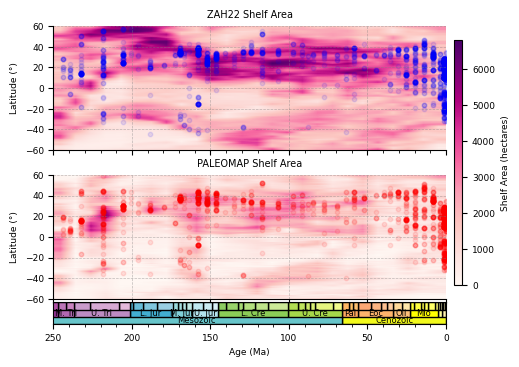

In [250]:
from scipy.interpolate import griddata
fig, axs = plt.subplots(2,1,figsize=(134*mm,90*mm))

# Create meshgrid for all age-latitude combinations
ages = ZAH22_shelfArea.columns
lats = ZAH22_shelfArea.index
# Create a 2D grid for the raster
Z = np.full((len(lats), len(ages)), np.nan)
for i, lat in enumerate(lats):
    for j, age in enumerate(ages):
        Z[i, j] = ZAH22_shelfArea.loc[lat, age]

# Make a normalised cmap to use for both plots
cmap = 'RdPu'
norm = plt.Normalize(vmin=0, vmax=np.nanmax(Z))

# Create the raster plot
im_ZAH22 = axs[0].imshow(Z, extent=[ages.min(), ages.max(), lats.min(), lats.max()], 
           aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')

# Create meshgrid for all age-latitude combinations
ages = scotese_shelfArea.columns
lats = scotese_shelfArea.index
# Create a 2D grid for the raster
Z = np.full((len(lats), len(ages)), np.nan)
for i, lat in enumerate(lats):
    for j, age in enumerate(ages):
        Z[i, j] = scotese_shelfArea.loc[lat, age]
# Create the raster plot
im_scotese = axs[1].imshow(Z, extent=[ages.min(), ages.max(), lats.min(), lats.max()], 
           aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')

axs[0].scatter(basicParedData.df['age'], basicParedData.df['ZAH22_lats'], color='blue', alpha=0.1, marker='o', s=10)
axs[1].scatter(basicParedData.df['age'], basicParedData.df['scotese_lats'], color='red', alpha=0.1, marker='o', s=10)    

axs[0].set_title('ZAH22 Shelf Area', fontsize=7)
axs[1].set_title('PALEOMAP Shelf Area', fontsize=7)

axs[0].set_xlim([250,0])
axs[1].set_xlim([250,0])
axs[0].set_xticks(np.arange(0, 251, 50))
# axs[0].set_yticks(np.arange(15, 29.5, 1), minor=True)
axs[0].set_xticks(np.arange(0, 251, 10), minor=True)
# Customize grid appearance
axs[0].xaxis.remove_overlapping_locs = False
axs[0].yaxis.remove_overlapping_locs = False
# axs[0].xaxis.set_visible(False)
# Remove axis tick labels
axs[0].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labelsize=6.5)

axs[0].set_ylim([-60,60])
axs[1].set_ylim([-60,60])
axs[0].set_ylabel('Latitude (°)', fontsize='6.5')
axs[1].set_ylabel('Latitude (°)', fontsize='6.5')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[0].grid(visible=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
axs[1].grid(visible=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
axs[1].tick_params(axis='x', labelbottom=False)
cbar = fig.colorbar(im_ZAH22, ax=axs, orientation='vertical', fraction=0.02, pad=0.02, label='Shelf Area (hectares)', aspect=30)
cbar.ax.tick_params(labelsize=6.5)
cbar.set_label('Shelf Area (hectares)', fontsize=6.5)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([axs[0].get_position().x0, 0.04, axs[0].get_position().width, 0.06], sharex=axs[0])
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)', fontsize='6.5')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

fig.savefig(f'figures/{fossilID}_shelf_area_distribution.png', dpi=300, transparent=True, bbox_inches='tight')


## Mapview snapshots

In [255]:
# Figure for a single snapshot
# age = 100
co2_scenario = 'PhanDA_SST'
ZAH22Scenario.fuzzyModelName = f'proj_ZAH22_paleomag/{co2_scenario}'
scoteseScenario.fuzzyModelName = f'proj_scotese/{co2_scenario}'

figFolder = 'figures'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)

fig = pygmt.Figure()
nrows = 5 # Number of rows in the subplot
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
ages =[217.75,158.15,117.2,97.2,13.8]
# ages = [204.95, 197.15, 179.15, 91.85, 51.9]
ages = [int((age+5)//10 * 10) for age in ages] # round the ages to nearest 10 for the co2 matchj scenarios (as opposed to best match scenario)
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=2,
    figsize=("18c", f"{nrows*4.5}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):
    with fig.set_panel(panel=0):
        coral_suitbility_plot(fig, ages[0], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[0]+5)//10 * 10
        fig.text(font='7p', text='Zahirovic (2022) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        co2 = ZAH22_matchingScenarios[co2_scenario][ages[0]]       
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=1):
        coral_suitbility_plot(fig, ages[0], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[0]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[0]) & (mergedAges['End'] <= ages[0])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)
        
        fig.text(font='7p', text='Scotese (2021) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[0]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")      
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
    with fig.set_panel(panel=2):
        coral_suitbility_plot(fig, ages[1], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[1]+5)//10 * 10
        co2 = ZAH22_matchingScenarios[co2_scenario][ages[1]]
        
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=3):
        coral_suitbility_plot(fig, ages[1], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[1]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[1]) & (mergedAges['End'] <= ages[1])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[1]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=4):
        coral_suitbility_plot(fig, ages[2], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[2]+5)//10 * 10
        co2 = ZAH22_matchingScenarios[co2_scenario][ages[2]]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=5):
        coral_suitbility_plot(fig, ages[2], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[2]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[2]) & (mergedAges['End'] <= ages[2])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.60c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.60c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[2]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=6):
        coral_suitbility_plot(fig, ages[3], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[3]+5)//10 * 10
        co2 = ZAH22_matchingScenarios[co2_scenario][ages[3]]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=7):
        coral_suitbility_plot(fig, ages[3], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[3]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[3]) & (mergedAges['End'] <= ages[3])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)    
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.80c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[3]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")   
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=8):
        coral_suitbility_plot(fig, ages[4], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        co2 = ZAH22_matchingScenarios[co2_scenario][ages[4]]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=9):
        coral_suitbility_plot(fig, ages[4], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        ageName = mergedAges[(mergedAges['Start'] > ages[4]) & (mergedAges['End'] <= ages[4])]['Name'].values[0].split('-')
        fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset="0.80c/-0.45c",verbose=True, no_clip=True)        
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset="0.80c/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        co2 = scotese_matchingScenarios[co2_scenario][ages[4]]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")

fig.colorbar(frame='a0.2+lCoral Suitability Score', position="JBC", box=None, cmap='data/cpt_files/reefProbFuzzy.cpt', verbose=True)
fig.show()
fig.savefig(f'{figFolder}/{fossilID}_fuzzy_logic_snapshots_{co2_scenario}.png', dpi=300, transparent=True)




makecpt [ERROR]: GMT_Read_Data: File not found: reefProbFuzzy


GMTCLibError: Module 'makecpt' failed with status code 16:
makecpt [ERROR]: GMT_Read_Data: File not found: reefProbFuzzy

## Probability-age plots


In [ ]:
ZAH22_probs = {}
scotese_probs = {}
combinedDF = pd.DataFrame()
ages2plot = mergedAges['MeanAge'].to_list()
ages2plot = [age for age in ages2plot if age <= 253]  # Filter out negative ages
for age in ages2plot:   
    print('\n')
    try:  
        model_prefix='ZAH22'
        climateScenarioClass = ZAH22Scenario
        probsDF = sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix)
        ZAH22_probs[age] = (np.nanmean(probsDF[f'{model_prefix}Probability']), stats.sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit'), np.sum(~np.isnan(probsDF[f'{model_prefix}Probability'])))

        model_prefix='scotese'
        climateScenarioClass = scoteseScenario
        probsDF = sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix, select=probsDF)
        scotese_probs[age] = (np.nanmean(probsDF[f'{model_prefix}Probability']), stats.sem(probsDF[f'{model_prefix}Probability'], nan_policy='omit'), np.sum(~np.isnan(probsDF[f'{model_prefix}Probability'])))
        combinedDF = pd.concat([combinedDF, probsDF], ignore_index=True)
    except Exception as e:
        print(f"Error processing age {age}: {e}")
        continue

combinedDF['epoch'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestGeologicalAge(age, level='Epoch'))
combinedDF['geoAge'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestGeologicalAge(age, level='Age'))

In [ ]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

# Remove probs with sizes less than 10
ZAH22_probs = {k: v for k, v in ZAH22_probs.items() if v[2] >= 5}
scotese_probs = {k: v for k, v in scotese_probs.items() if v[2] >= 5}

ax.plot(ZAH22_probs.keys(), list(zip(*ZAH22_probs.values()))[0], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
ax.errorbar(ZAH22_probs.keys(), list(zip(*ZAH22_probs.values()))[0], yerr=list(zip(*ZAH22_probs.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese2021)')
ax.errorbar(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], yerr=list(zip(*scotese_probs.values()))[1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')
ax.xaxis.set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 61, 10))
ax2.set_ylabel('No. of Unique Reef Localities')

epochBins = [0] + epochs['Start'].tolist()
ageBins = [0] + mergedAges['Start'].tolist()
# Plot histograms for the two models using the 'age' column, filtering for non-null probabilities
ax2.hist(combinedDF.loc[combinedDF['ZAH22Probability'].notna(), 'age'], bins=ageBins, color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
ax2.hist(combinedDF.loc[combinedDF['scoteseProbability'].notna(), 'age'], bins=ageBins, color='red', alpha=0.5, label='Paleogeography Model #2 (PALEOMAP)')

ax2.plot([], [], color='black', linestyle=':', label='No. of Unique Reef Localities')

ax.legend(loc='upper right', ncol=1, frameon=False)
# ax2.legend(loc='lower center', ncol=1, frameon=False)

# Hide the right and top spines
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
fig.savefig(f'{figFolder}/{fossilID}_fuzzy_logic_probabilities_{co2_scenario}.png', dpi=300, transparent=True)

# Best match

In [ ]:
ZAH22_CO2s = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
ZAH22_CO2s_sems = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
scotese_CO2s = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
scotese_CO2s_sems = pd.DataFrame(index=mergedAges['MeanAge'].to_list())
for co2 in co2s:
    aveProbsZAH22 = {}
    semsProbsZAH22 = {}
    aveProbsScotese = {}
    semsProbsScotese = {}
    for age in mergedAges['MeanAge'].to_list(): 
    # for age in [13.8]:
        if age > 253:
            continue
        model_prefix='ZAH22'
        climateScenarioClass = ZAH22Scenario
        try:
            probsDF = sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix, prescribeCO2=co2)
            if len(probsDF) < 4:
                continue
            aveProbsZAH22[age] = probsDF[f'{model_prefix}Probability'].mean()
            semsProbsZAH22[age] = probsDF[f'{model_prefix}Probability'].sem()
        except Exception as e:
            print(f"Error processing age {age} for {model_prefix} with CO2 {co2}: {e}")
            aveProbsZAH22[age] = np.nan
            continue
        # allCO2s[f'{model_prefix}_' + str(co2)] = probsDF[f'{model_prefix}Probability']

        model_prefix='scotese'
        climateScenarioClass = scoteseScenario
        try:
            probsDF = sample_probabilities(age, climateScenarioClass, basicParedData, mergedAges, model_prefix=model_prefix, prescribeCO2=co2)
            aveProbsScotese[age] = probsDF[f'{model_prefix}Probability'].mean()
            semsProbsScotese[age] = probsDF[f'{model_prefix}Probability'].sem()
        except Exception as e:
            print(f"Error processing age {age} for {model_prefix} with CO2 {co2}: {e}")
            aveProbsScotese[age] = np.nan


    ZAH22_CO2s[f'ZAH22_{co2}'] = pd.Series(aveProbsZAH22)
    ZAH22_CO2s_sems[f'ZAH22_{co2}'] = pd.Series(semsProbsZAH22)
    scotese_CO2s[f'scotese_{co2}'] = pd.Series(aveProbsScotese)
    scotese_CO2s_sems[f'scotese_{co2}'] = pd.Series(semsProbsScotese)

In [ ]:
optimalCO2s_ZAH22 = {}
for age in ZAH22_CO2s.index:
    row = ZAH22_CO2s.loc[age]
    max = row.idxmax()
    maxProb = row.max()

    # If the difference between the max probability and the adjacent probabilities is less than the standard error, then choose the probability of the higher co2/index
    if maxProb > 0:
        # maxDiff = ZAH22_CO2s.loc[age][max] - ZAH22_CO2s.loc[age].drop(max).max()
        maxIndex = ZAH22_CO2s.columns.get_loc(max)
        # sys.exit()
        # maxDiff = row.iloc[maxIndex] - row.iloc[maxIndex + 1]
        semMaxProb = ZAH22_CO2s_sems.loc[age][max]
        minRange = maxProb - semMaxProb
        maxRange = maxProb + semMaxProb

        print(f'The range of uncertainty for {age}Ma is {minRange:.2f} to {maxRange:.2f}. The maximum probability is {maxProb:.2f} with an sem of {semMaxProb:.2f}.')

        # Choose columns that sit within the min and max ranges
        selected_columns = ZAH22_CO2s.loc[age][(ZAH22_CO2s.loc[age] >= minRange) & (ZAH22_CO2s.loc[age] <= maxRange)].index
        age10 = (age + 5)//10 * 10
        maxGMST = ZAH22_modelGMST_df[max.split('_')[1]][age10]
        maxSST = ZAH22_modelSST_df[max.split('_')[1]][age10]
        maxSongSST = ZAH22_songSST_df[max.split('_')[1]][age10]
        maxTropicalAir = ZAH22_model_tropicalAirTemp[max.split('_')[1]][age10]
        GMSTs = []
        SSTs = []
        songSSTs = []
        tropicalAirTemps = []
        for col in selected_columns:
            GMST = ZAH22_modelGMST_df[col.split('_')[1]][age10]
            SST = ZAH22_modelSST_df[col.split('_')[1]][age10]
            songSST = ZAH22_songSST_df[col.split('_')[1]][age10]
            tropicalAir = ZAH22_model_tropicalAirTemp[col.split('_')[1]][age10]
            GMSTs.append(GMST)
            SSTs.append(SST)
            songSSTs.append(songSST)
            tropicalAirTemps.append(tropicalAir)

        optimalCO2s_ZAH22[age] = (selected_columns.tolist(), maxProb, maxGMST, GMSTs, maxSST, SSTs, maxSongSST, songSSTs, maxTropicalAir, tropicalAirTemps, semMaxProb)
        print('\n')
GMSTS_ZAH22 = list(zip(*optimalCO2s_ZAH22.values()))[3]
GMSTS_max_ZAH22 = [np.max(gmsts) for gmsts in GMSTS_ZAH22]
GMSTS_min_ZAH22 = [np.min(gmsts) for gmsts in GMSTS_ZAH22]

SSTs_ZAH22 = list(zip(*optimalCO2s_ZAH22.values()))[5]
SSTs_max_ZAH22 = [np.max(ssts) for ssts in SSTs_ZAH22]
SSTs_min_ZAH22 = [np.min(ssts) for ssts in SSTs_ZAH22]

songSSTs_ZAH22 = list(zip(*optimalCO2s_ZAH22.values()))[7]
songSSTs_max_ZAH22 = [np.max(songSSTs) for songSSTs in songSSTs_ZAH22]
songSSTs_min_ZAH22 = [np.min(songSSTs) for songSSTs in songSSTs_ZAH22]

tropicalAirTemps_ZAH22 = list(zip(*optimalCO2s_ZAH22.values()))[9]
tropicalAirTemps_max_ZAH22 = [np.max(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_ZAH22]
tropicalAirTemps_min_ZAH22 = [np.min(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_ZAH22]

optimalCO2s_scotese = {}
for age in scotese_CO2s.index:
    row = scotese_CO2s.loc[age]
    max = row.idxmax()
    maxProb = row.max()

    # If the difference between the max probability and the adjacent probabilities is less than the standard error, then choose the probability of the higher co2/index
    if maxProb > 0:
        # maxDiff = scotese_CO2s.loc[age][max] - scotese_CO2s.loc[age].drop(max).max()
        maxIndex = scotese_CO2s.columns.get_loc(max)
        # sys.exit()
        # maxDiff = row.iloc[maxIndex] - row.iloc[maxIndex + 1]
        semMaxProb = scotese_CO2s_sems.loc[age][max]
        minRange = maxProb - semMaxProb
        maxRange = maxProb + semMaxProb

        print(f'The range of uncertainty for {age}Ma is {minRange:.2f} to {maxRange:.2f}. The maximum probability is {maxProb:.2f} with an sem of {semMaxProb:.2f}.')

        # Choose columns that sit within the min and max ranges
        selected_columns = scotese_CO2s.loc[age][(scotese_CO2s.loc[age] >= minRange) & (scotese_CO2s.loc[age] <= maxRange)].index
        age10 = (age + 5)//10 * 10
        maxGMST = scotese_modelGMST_df[max.split('_')[1]][age10]
        maxSST = scotese_modelSST_df[max.split('_')[1]][age10]
        maxSongSST = scotese_songSST_df[max.split('_')[1]][age10]
        maxTropicalAir = scotese_model_tropicalAirTemp[max.split('_')[1]][age10]
        GMSTs = []
        SSTs = []
        songSSTs = []
        tropicalAirTemps = []
        for col in selected_columns:
            GMST = scotese_modelGMST_df[col.split('_')[1]][age10]
            GMSTs.append(GMST)
            SST = scotese_modelSST_df[col.split('_')[1]][age10]
            SSTs.append(SST)
            songSST = scotese_songSST_df[col.split('_')[1]][age10]
            songSSTs.append(songSST)
            tropicalAir = scotese_model_tropicalAirTemp[col.split('_')[1]][age10]
            tropicalAirTemps.append(tropicalAir)

        optimalCO2s_scotese[age] = (selected_columns.tolist(), maxProb, maxGMST, GMSTs, maxSST, SSTs, maxSongSST, songSSTs, maxTropicalAir, tropicalAirTemps, semMaxProb)
        print('\n')

GMSTS_scotese = list(zip(*optimalCO2s_scotese.values()))[3]
GMSTS_max_scotese = [np.max(gmsts) for gmsts in GMSTS_scotese]
GMSTS_min_scotese = [np.min(gmsts) for gmsts in GMSTS_scotese]

SSTs_scotese = list(zip(*optimalCO2s_scotese.values()))[5]
SSTs_max_scotese = [np.max(ssts) for ssts in SSTs_scotese]
SSTs_min_scotese = [np.min(ssts) for ssts in SSTs_scotese]

songSSTs_scotese = list(zip(*optimalCO2s_scotese.values()))[7]
songSSTs_max_scotese = [np.max(songSSTs) for songSSTs in songSSTs_scotese]
songSSTs_min_scotese = [np.min(songSSTs) for songSSTs in songSSTs_scotese]

tropicalAirTemps_scotese = list(zip(*optimalCO2s_scotese.values()))[9]
tropicalAirTemps_max_scotese = [np.max(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_scotese]
tropicalAirTemps_min_scotese = [np.min(tropicalAirTemps) for tropicalAirTemps in tropicalAirTemps_scotese]


In [ ]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

# Remove probs with sizes less than 10
ZAH22_probs = {k: v for k, v in ZAH22_probs.items() if v[2] >= 5}
scotese_probs = {k: v for k, v in scotese_probs.items() if v[2] >= 5}

ax.plot(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[1], linewidth=1.2, color='blue', label='ZAH22')
ax.errorbar(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[1], yerr=list(zip(*optimalCO2s_ZAH22.values()))[-1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[1], linewidth=1.2, color='red', label='PALEOMAP')
ax.errorbar(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[1], yerr=list(zip(*optimalCO2s_scotese.values()))[-1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')
ax.xaxis.set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 61, 10))
ax2.set_ylabel('Unique Coral Sites')

epochBins = [0] + epochs['Start'].tolist()
ageBins = [0] + mergedAges['Start'].tolist()
# Plot histograms for the two models using the 'age' column, filtering for non-null probabilities
ax2.hist(combinedDF.loc[combinedDF['ZAH22Probability'].notna(), 'age'], bins=ageBins, color='blue', alpha=0.5, label='ZAH22')
ax2.hist(combinedDF.loc[combinedDF['scoteseProbability'].notna(), 'age'], bins=ageBins, color='red', alpha=0.5, label='PALEOMAP')

ax2.plot([], [], color='black', linestyle=':')

# fig.legend(loc='center left', ncol=1, frameon=False, bbox_to_anchor=(0.91, 0.5))
ax.legend(loc='center left', ncol=1, frameon=True, facecolor='white', bbox_to_anchor=(0.8, 0.45), fontsize=8)
# ax2.legend(loc='center left', ncol=1, frameon=False, bbox_to_anchor=(0, 0.5), fontsize=8)

# Hide the right and top spines
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
fig.savefig(f'{figFolder}/{fossilID}_fuzzy_logic_probabilities_optimalCO2s.png', dpi=300, transparent=True)

In [ ]:
combinedDF.loc[combinedDF['geoAge'] == 'Priabonian', ]

# Best match snapshots

In [ ]:
ZAH22_bestScenario = pd.DataFrame(index=mergedAges['MeanAge'].to_list(), columns=['best_scenario'])
prefix = 'proj_ZAH22_paleomag'
co2s_probs = ZAH22_CO2s
bestScenario = ZAH22_bestScenario

fuzzy_logic_dir = f'data/fuzzy_logic_projection/{prefix}/best_scenario'
if not os.path.exists(fuzzy_logic_dir):
    os.makedirs(fuzzy_logic_dir)

for age in co2s_probs.index:
    probs = co2s_probs.loc[age]
    highest_prob_co2 = probs.idxmax()
    if highest_prob_co2 is np.nan:
        continue
    bestScenario['best_scenario'][age] = highest_prob_co2

    age10 = (age + 5)//10 * 10
    co2 = highest_prob_co2.split('_')[1]

    selected_model = f'data/fuzzy_logic_projection/{prefix}/{co2}ppm/{round(age10)}Ma.nc'
    shutil.copy(selected_model, f'{fuzzy_logic_dir}/{round(age, 4)}Ma.nc')

scotese_bestScenario = pd.DataFrame(index=mergedAges['MeanAge'].to_list(), columns=['best_scenario'])
prefix = 'proj_scotese'
co2s_probs = scotese_CO2s
bestScenario = scotese_bestScenario

fuzzy_logic_dir = f'data/fuzzy_logic_projection/{prefix}/best_scenario'
if not os.path.exists(fuzzy_logic_dir):
    os.makedirs(fuzzy_logic_dir)

for age in co2s_probs.index:
    probs = co2s_probs.loc[age]
    highest_prob_co2 = probs.idxmax()
    if highest_prob_co2 is np.nan:
        continue
    # bestScenario['best_scenario'][age] = highest_prob_co2
    bestScenario.loc[age, 'best_scenario'] = highest_prob_co2

    age10 = (age + 5)//10 * 10
    co2 = highest_prob_co2.split('_')[1]

    selected_model = f'data/fuzzy_logic_projection/{prefix}/{co2}ppm/{round(age10)}Ma.nc'
    shutil.copy(selected_model, f'{fuzzy_logic_dir}/{round(age, 4)}Ma.nc')

In [ ]:
# Figure for a single snapshot
# age = 100
co2_scenario = 'best_scenario'
ZAH22Scenario.fuzzyModelName = f'proj_ZAH22_paleomag/{co2_scenario}'
scoteseScenario.fuzzyModelName = f'proj_scotese/{co2_scenario}'
# scoteseScenario.fuzzyModelName = f'proj_ZAH22_paleomag/{co2_scenario}'
# ZAH22TopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_ZAH22/topos_filled_PaleomagRef"
# scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ZAH22Scenario.topoPath = ZAH22TopoPath
scoteseScenario.topoPath = scoteseTopoPath

figFolder = 'figures'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)

fig = pygmt.Figure()
nrows = 5 # Number of rows in the subplot
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
# ages =[204.95,158.15,106.75,58.8, 19.5]
ages = [204.95, 197.15, 158.15, 91.85, 51.9]
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=2,
    figsize=("18c", f"{nrows*4.5}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):
    with fig.set_panel(panel=0):
        coral_suitbility_plot(fig, ages[0], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[0]+5)//10 * 10
        fig.text(font='7p', text='ZAH22 Paleogeographic Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        co2 = ZAH22_bestScenario[co2_scenario][ages[0]].split('_')[1]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=1):
        coral_suitbility_plot(fig, ages[0], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[0]) & (mergedAges['End'] < ages[0])]['Name'].values[0].split('-')
        age10 = (ages[0]+5)//10 * 10
        text_y_offset = '0.80c'
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.45c",verbose=True, no_clip=True)
        else:
            fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset=f"{text_y_offset}/0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[0]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[0])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
    with fig.set_panel(panel=2):
        coral_suitbility_plot(fig, ages[1], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[1]+5)//10 * 10
        co2 = ZAH22_bestScenario[co2_scenario][ages[1]].split('_')[1]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=3):
        coral_suitbility_plot(fig, ages[1], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[1]) & (mergedAges['End'] < ages[1])]['Name'].values[0].split('-')
        age10 = (ages[1]+5)//10 * 10
        text_y_offset = '0.80c'
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.45c",verbose=True, no_clip=True)
        else:
            fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset=f"{text_y_offset}/0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[1]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[1])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=4):
        coral_suitbility_plot(fig, ages[2], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[2]+5)//10 * 10
        co2 = ZAH22_bestScenario[co2_scenario][ages[2]].split('_')[1]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=5):
        coral_suitbility_plot(fig, ages[2], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[2]) & (mergedAges['End'] < ages[2])]['Name'].values[0].split('-')
        age10 = (ages[2]+5)//10 * 10
        text_y_offset = '0.80c'
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.45c",verbose=True, no_clip=True)
        else:
            fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset=f"{text_y_offset}/0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[2]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[2])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=6):
        coral_suitbility_plot(fig, ages[3], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[3]+5)//10 * 10
        co2 = ZAH22_bestScenario[co2_scenario][ages[3]].split('_')[1]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=7):
        coral_suitbility_plot(fig, ages[3], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[3]) & (mergedAges['End'] < ages[3])]['Name'].values[0].split('-')
        age10 = (ages[3]+5)//10 * 10
        text_y_offset = '0.80c'
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.45c",verbose=True, no_clip=True)
        else:
            fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset=f"{text_y_offset}/0.15c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.80c/0c",verbose=True, no_clip=True)
        # fig.text(font='7p', text=f'{ageName}', position="MR", justify="MC", offset="0.80c/-0.15c",verbose=True, no_clip=True)
        co2 = scotese_bestScenario[co2_scenario][ages[3]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[3])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=8):
        coral_suitbility_plot(fig, ages[4], ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
        age10 = (ages[4]+5)//10 * 10
        co2 = ZAH22_bestScenario[co2_scenario][ages[4]].split('_')[1]
        gmst = ZAH22_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        
        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
    with fig.set_panel(panel=9):
        coral_suitbility_plot(fig, ages[4], scoteseScenario, basicParedData, mergedAges, model_prefix='scotese', figFolder=figFolder)
        ageName = mergedAges[(mergedAges['Start'] >= ages[4]) & (mergedAges['End'] < ages[4])]['Name'].values[0].split('-')
        age10 = (ages[4]+5)//10 * 10
        text_y_offset = '0.80c'
        if len(ageName) > 1:
            fig.text(font='7p', text=f'{ageName[0]} -', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
            fig.text(font='7p', text=f'{ageName[1]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.45c",verbose=True, no_clip=True)
        else:
            fig.text(font='7p', text=f'{ageName[0]}', position="MR", justify="MC", offset=f"{text_y_offset}/-0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'{int(age10)} Ma', position="MR", justify="MC", offset=f"{text_y_offset}/0.15c",verbose=True, no_clip=True)
        
        co2 = scotese_bestScenario[co2_scenario][ages[4]].split('_')[1]
        gmst = scotese_modelGMST_df[co2][age10]
        if co2 == 'fosterCO2':
            co2 = convert_foster(ages[4])
        fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.5p,black", fill="white")

        
        fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")

fig.colorbar(frame='a0.2+lCoral Suitability Score', position="JBC", box=None, cmap='reefProbFuzzy.cpt', verbose=True)
fig.show()
fig.savefig(f'{figFolder}/{fossilID}_snapshots_best_scenario.png', dpi=300)

### All ages

In [ ]:
mergedAges_mesoCeno = mergedAges[mergedAges['MeanAge'] <= 250]

co2_scenario = 'best_scenario'
ZAH22Scenario.fuzzyModelName = f'proj_ZAH22_paleomag/{co2_scenario}'
scoteseScenario.fuzzyModelName = f'proj_scotese/{co2_scenario}'
# scoteseScenario.fuzzyModelName = f'proj_ZAH22_paleomag/{co2_scenario}'
# ZAH22TopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_ZAH22/topos_filled_PaleomagRef"
# scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ZAH22Scenario.topoPath = ZAH22TopoPath
scoteseScenario.topoPath = scoteseTopoPath

figFolder = 'figures'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)

fig = pygmt.Figure()
nrows = 9 # Number of rows in the subplot
ncols = 4
geographyScenario = scoteseScenario
if geographyScenario == ZAH22Scenario:
    bestScenario = ZAH22_bestScenario
    gmstDF = ZAH22_modelGMST_df
    figLabel = 'ZAH22'
elif geographyScenario == scoteseScenario:
    bestScenario = scotese_bestScenario
    gmstDF = scotese_modelGMST_df
    figLabel = 'scotese'
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
# ages =[204.95,158.15,106.75,58.8, 19.5]
ages = mergedAges_mesoCeno['MeanAge'].to_list()
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=ncols,
    figsize=(f"{ncols*6}c", f"{nrows*3}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):

    panel = 0
    for i in range(len(ages)):
        age = ages[i]
        co2 = bestScenario[co2_scenario][age]
        if co2 is np.nan:
            print(f"No best scenario for age {age} in {figLabel}.")
            continue
        co2 = co2.split('_')[1]
        with fig.set_panel(panel=panel):
            try:
                coral_suitbility_plot(fig, age, geographyScenario, basicParedData, mergedAges, model_prefix=figLabel, figFolder=figFolder)
            except Exception as e:
                print(f"Error plotting {figLabel} for age {age}: {e}")
                continue
            # fig.text(font='6.5p', text=f'CO@-2@-: {co2} ppm', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
            fig.text(font='6.5p', text=f'{age} Ma', position="TL", justify="MC", offset="0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
            age10 = (ages[0]+5)//10 * 10
            gmst = gmstDF[co2][age10]
            fig.text(font='6.5p', text=f'GMST: {gmst:.1f} °C', position="TR", justify="MC", offset="-0.9c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        panel += 1
fig.show()
fig.savefig(f'{figFolder}/{fossilID}_snapshots_all_ages_{figLabel}_best_scenario.png', dpi=300)

### Animation

In [ ]:
# mergedAges.head(60)
ageName = mergedAges[(mergedAges['Start'] >= ages[3]) & (mergedAges['End'] < ages[3])]['Name'].values[0]
ageName

In [ ]:
inputDir = f'data/fuzzy_logic_projection/proj_ZAH22_paleomag/best_scenario'
print(inputDir)

In [ ]:
figFolder = 'figures/animation'
if not os.path.exists(figFolder):
    os.makedirs(figFolder)
for file in os.listdir(inputDir):
    if file.endswith('.nc'):
        age = float(file.replace('Ma.nc',''))
        age10 = (age + 5)//10 * 10
        print(age)
        fig = pygmt.Figure()
        nrows = 1 # Number of rows in the subplot
        anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
        ages =[217.75,158.15,117.2,97.2,58.8, 19.5]
        pygmt.config(MAP_FRAME_TYPE="plain")
        with fig.subplot(
            nrows=nrows,
            ncols=1,
            figsize=("18c", f"{nrows*4.5}c"),
            sharex="b",
            sharey="l",
            margins=["0.35c", "0c"], 
            frame=['WSrt','xa120f30','ya60f30'],
        ):
            with fig.set_panel(panel=0):
                coral_suitbility_plot(fig, age, ZAH22Scenario, basicParedData, mergedAges, model_prefix='ZAH22', figFolder=figFolder)
                fig.text(font='7p', text=f'{int(age10)} Ma', position="TR", justify="MC", offset="-0.6c/-0.2c",verbose=True, no_clip=True, pen="0.1p,black", fill="white")
        # fig.show()
        fig.savefig(f'{figFolder}/{age}_{fossilID}_bestCase.png', dpi=300)

In [ ]:
import imageio
import re
def animation(directory,name='animation.gif'):
    def extract_starting_integer(s):
        match = re.match(r'(\d+)', s)
        return int(match.group(1)) if match else float('inf')

    images = []
    for im in sorted(os.listdir(directory), key=extract_starting_integer):
        print(im)
        if not im.endswith('png'):
            continue
        images.append(imageio.v2.imread(f'{directory}/{im}'))
    print(f'Creating animation gif with {len(images)} frames.')
    imageio.mimwrite(f'{directory}/{name}',images, duration=500)

animation(figFolder, name=f'{fossilID}_fuzzy_logic_projection_ZAH22_paleomag_best_scenario.gif')

# Paleotemps comparison

In [ ]:
colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']
colourDict = {}
ptempCurveColours =['black','mediumvioletred','grey']
ptempCurveLinewidth = 0.5
co2MarkerSize = 15
co2MarkerLinewidth = 0.5
figFolder = 'figures'

markers = []
labels = []
for i, co2 in enumerate(co2s):
    colour = colours[i]
    colourDict[co2] = colour
    marker = mlines.Line2D([], [], color=colour, marker='*', linestyle='None', markersize=5, markeredgewidth=0.3, markeredgecolor='black', label=f'{co2}')
    markers.append(marker)

    if co2 == 'fosterCO2':
        label = 'Foster2017'
    else:
        label = f'{co2} ppm'
    labels.append(label)
# Plot all four figures
fig, axs = plt.subplots(4, 2, figsize=(134*mm,180*mm), dpi=300, sharex=True, sharey=True)
plt.rcParams['font.size']=6.5
plt.subplots_adjust(wspace=0.08, hspace=0.1)  # Reduce horizontal and vertical space between subplots
# Set Y-axis limits
axs[0,0].set_ylim(7, 39)
axs[0,0].set_xlim(255,-3.2)
axs[0,0].set_xticks(np.arange(0, 251, 50))
axs[0,0].set_xticks(np.arange(0, 251, 10), minor=True)
axs[0,0].xaxis.remove_overlapping_locs = False

# Plot paleo temperature curves
axs[0, 0].plot(sco21_OGtemps.index, sco21_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-',label='SCO21')
axs[0, 1].plot(sco21_OGtemps.index, sco21_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='SCO21')
axs[0, 0].plot(merdithOGtemps.index, merdithOGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[1], linestyle='-', label='MER25')
axs[0, 1].plot(merdithOGtemps.index, merdithOGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[1], linestyle='-', label='MER25')
axs[0, 0].plot(phanDA_OGtemps.index, phanDA_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[2], linestyle='-', label='PhanDA')
axs[0, 1].plot(phanDA_OGtemps.index, phanDA_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[2], linestyle='-', label='PhanDA')
axs[1,0].plot(grossmann_OGtemps.index, grossmann_OGtemps['GRO22'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='GRO22')
axs[1,1].plot(grossmann_OGtemps.index, grossmann_OGtemps['GRO22'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='GRO22')
axs[1,0].plot(phandDA_SST_OGtemps.index, phandDA_SST_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[2], linestyle='-', label='PhanDA')
axs[1,1].plot(phandDA_SST_OGtemps.index, phandDA_SST_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[2], linestyle='-', label='PhanDA')
axs[2,0].plot(song_OGtemps.index, song_OGtemps['SONG19'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='SONG19')
axs[2,1].plot(song_OGtemps.index, song_OGtemps['SONG19'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='SONG19')
axs[3,0].plot(sco21_tropicalAir_OGtemps.index, sco21_tropicalAir_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='SCO21')
axs[3,1].plot(sco21_tropicalAir_OGtemps.index, sco21_tropicalAir_OGtemps['paleoTemp'], linewidth=ptempCurveLinewidth, color=ptempCurveColours[0], linestyle='-', label='SCO21')

for i, co2 in enumerate(co2s): 
    axs[0, 0].scatter(x=ZAH22_modelGMST_df.index, y=ZAH22_modelGMST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[0, 1].scatter(x=scotese_modelGMST_df.index, y=scotese_modelGMST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[1, 0].scatter(x=ZAH22_modelSST_df.index, y=ZAH22_modelSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[1, 1].scatter(x=scotese_modelSST_df.index, y=scotese_modelSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[2, 0].scatter(x=ZAH22_songSST_df.index, y=ZAH22_songSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[2, 1].scatter(x=scotese_songSST_df.index, y=scotese_songSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[3, 0].scatter(x=ZAH22_model_tropicalAirTemp.index, y=ZAH22_model_tropicalAirTemp[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)
    axs[3, 1].scatter(x=scotese_model_tropicalAirTemp.index, y=scotese_model_tropicalAirTemp[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=co2MarkerLinewidth, s=co2MarkerSize, alpha=0.5, zorder=0)

# Add in the ideal scenario based on coral likelihood
axs[0,0].plot(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[2], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', label='ZAH22 Best Match', zorder=20)
# axs[0,0].scatter(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[2], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[0,0].fill_between(optimalCO2s_ZAH22.keys(), GMSTS_min_ZAH22, GMSTS_max_ZAH22, color='blue', alpha=0.15, zorder=30)

axs[0,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[2], linewidth=0.4, color='red', alpha=0.6, linestyle='--', label='PALEOMAP Best Match', zorder=20)
# axs[0,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[2], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[0,1].fill_between(optimalCO2s_scotese.keys(), GMSTS_min_scotese, GMSTS_max_scotese, color='red', alpha=0.15, zorder=30)

axs[1,0].plot(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[4], linewidth=0.4, color='blue', alpha=0.6, linestyle='--',zorder=20)
# axs[1,0].scatter(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[4], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[1,0].fill_between(optimalCO2s_ZAH22.keys(), SSTs_min_ZAH22, SSTs_max_ZAH22, color='blue', alpha=0.15, zorder=30)

axs[1,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[4], linewidth=0.4, color='red', alpha=0.6, linestyle='--', zorder=20)
# axs[1,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[4], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[1,1].fill_between(optimalCO2s_scotese.keys(), SSTs_min_scotese, SSTs_max_scotese, color='red', alpha=0.15, zorder=30)

axs[2,0].plot(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[6], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', zorder=20)
# axs[2,0].scatter(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[6], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[2,0].fill_between(optimalCO2s_ZAH22.keys(), songSSTs_min_ZAH22, songSSTs_max_ZAH22, color='blue', alpha=0.15, zorder=30)

axs[2,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[6], linewidth=0.4, color='red', alpha=0.6, linestyle='--', zorder=20)
# axs[2,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[6], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[2,1].fill_between(optimalCO2s_scotese.keys(), songSSTs_min_scotese, songSSTs_max_scotese, color='red', alpha=0.15, zorder=30)

axs[3,0].plot(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[8], linewidth=0.4, color='blue', alpha=0.6, linestyle='--', zorder=20)
# axs[3,0].scatter(optimalCO2s_ZAH22.keys(), list(zip(*optimalCO2s_ZAH22.values()))[8], marker='o', color='blue', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[3,0].fill_between(optimalCO2s_ZAH22.keys(), tropicalAirTemps_min_ZAH22, tropicalAirTemps_max_ZAH22, color='blue', alpha=0.15, zorder=30)

axs[3,1].plot(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[8], linewidth=0.4, color='red', alpha=0.6, linestyle='--', zorder=20)
# axs[3,1].scatter(optimalCO2s_scotese.keys(), list(zip(*optimalCO2s_scotese.values()))[8], marker='o', color='red', s=co2MarkerSize/6, alpha=0.6, edgecolors='blue', linewidths=0)
axs[3,1].fill_between(optimalCO2s_scotese.keys(), tropicalAirTemps_min_scotese, tropicalAirTemps_max_scotese, color='red', alpha=0.15, zorder=30)

colours_ZAH22 = {}
colours_scotese = {}
for age in optimalCO2s_ZAH22.keys():
    try:
        co2= ZAH22_bestScenario['best_scenario'][age].split('_')[1]
        colours_ZAH22[age] = colourDict[co2]

        
        co2= scotese_bestScenario['best_scenario'][age].split('_')[1]
        # print(f'{age}: {scotese_bestScenario["best_scenario"][age]} -> {co2}')
        colours_scotese[age] = colourDict[co2]
    except Exception as e:
        print(f'{scotese_bestScenario['best_scenario'][age]}')
        print(f"Error occurred: {e}")
        
        continue

# Plot the colour-coded co2 matches for the coral reconstructed temps
try:
    axs[0,0].scatter(x=list(optimalCO2s_ZAH22.keys()),y=list(zip(*optimalCO2s_ZAH22.values()))[2], marker='*', facecolors=list(colours_ZAH22.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[0,1].scatter(x=list(optimalCO2s_scotese.keys()),y=list(zip(*optimalCO2s_scotese.values()))[2], marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[1,0].scatter(x=list(optimalCO2s_ZAH22.keys()),y=list(zip(*optimalCO2s_ZAH22.values()))[4], marker='*', facecolors=list(colours_ZAH22.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[1,1].scatter(x=list(optimalCO2s_scotese.keys()),y=list(zip(*optimalCO2s_scotese.values()))[4], marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[2,0].scatter(x=list(optimalCO2s_ZAH22.keys()),y=list(zip(*optimalCO2s_ZAH22.values()))[6], marker='*', facecolors=list(colours_ZAH22.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[2,1].scatter(x=list(optimalCO2s_scotese.keys()),y=list(zip(*optimalCO2s_scotese.values()))[6], marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[3,0].scatter(x=list(optimalCO2s_ZAH22.keys()),y=list(zip(*optimalCO2s_ZAH22.values()))[8], marker='*', facecolors=list(colours_ZAH22.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
    axs[3,1].scatter(x=list(optimalCO2s_scotese.keys()),y=list(zip(*optimalCO2s_scotese.values()))[8], marker='*', facecolors=list(colours_scotese.values()), edgecolors='black', linewidths=0.2, s=co2MarkerSize, zorder=40)
except Exception as e:
    print(f"Error occurred: {e}")
    pass

# Set the x and y labels
axs[0, 0].set_ylabel('GMST (°C)', labelpad=3, fontsize=6.5)
axs[1, 0].set_ylabel('SST (30S-30N — °C)', labelpad=3, fontsize=6.5)
axs[2, 0].set_ylabel('SST (40S-40N — °C)', labelpad=3, fontsize=6.5)
axs[3, 0].set_ylabel('Tropical MST (15S-15N — °C)', labelpad=3, fontsize=6.5)
# axs[1, 0].set_xlabel('Age (Ma)', labelpad=3, fontsize=6.5)
# axs[1, 1].set_xlabel('Age (Ma)', labelpad=3, fontsize=6.5)
axs[3,0].tick_params(axis='x', labelbottom=False)
axs[3,1].tick_params(axis='x', labelbottom=False)

# Add column headings
axs[0,0].set_title('ZAH22 Paleogeography', fontsize=7, pad=10)
axs[0,1].set_title('PALEOMAP Paleogeography', fontsize=7, pad=10)

# Get handles and labels from both subplots
handles_00, labels_00 = axs[0,0].get_legend_handles_labels()
handles_01, labels_01 = axs[0,1].get_legend_handles_labels()
# Combine them
# coral_match_handle = handles_00[0] + handles_01[0]
# coral_match_label = labels_00[0] + labels_01[0]
# Remove coral match from handles_00 and labels_00
axs[0,0].legend([handles_00[-1]], [labels_00[-1]], bbox_to_anchor=(1, 0.85), loc='lower right', frameon=False, fontsize=5.5)
# Do a figure level legend because I apparently can't do two separate legends for the same subplot
fig.legend([handles_01[-1]], [labels_01[-1]], bbox_to_anchor=(0.668, 0.854), loc='lower left', frameon=False, fontsize=5.5)

# Get the remaining handles and labels from the first subplot (excluding the coral match)
handles_00_remaining = handles_00[:-1]
labels_00_remaining = labels_00[:-1]

# Create a separate legend for the remaining paleotemp curves on the right subplot
axs[0,1].legend(handles_00_remaining, labels_00_remaining, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5, ncol=2)
#

# axs[1,1].legend(loc='upper left', frameon=False, fontsize=6.5)

handles_10, labels_10 = axs[1,0].get_legend_handles_labels()
handles_10 = [handles_10[0]] + [handles_10[1]] 
labels_10 = [labels_10[0]] + [labels_10[1]] 
axs[1,1].legend(handles_10, labels_10, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5)

handles_20, labels_20 = axs[2,0].get_legend_handles_labels()
handles_20 = [handles_20[0]]
labels_20 = [labels_20[0]]
axs[2,1].legend(handles_20, labels_20, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5)

handles_30, labels_30 = axs[3,0].get_legend_handles_labels()
handles_30 = [handles_30[0]]
labels_30 = [labels_30[0]]
axs[3,1].legend(handles_30, labels_30, bbox_to_anchor=(1, 0.01), loc='lower right', frameon=False, fontsize=5.5)

axs[3,0].legend(markers, labels, bbox_to_anchor=(0, 0), loc='lower left', frameon=False, fontsize=5.5, ncol=3, handletextpad=0.25, columnspacing=0.5)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([axs[0,0].get_position().x0, 0.04, axs[0,0].get_position().width, 0.06], sharex=axs[0,0])
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1.5)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)', fontsize=6.5)
# Add x axis tick labels
ax0.set_xticks(np.arange(0, 251, 50))
ax0.set_xticks(np.arange(0, 251, 10), minor=True)

for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)

# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

ax01 = fig.add_axes([axs[0,1].get_position().x0, 0.04, axs[0,1].get_position().width, 0.06], sharex=axs[0,1])
ax01.set_xlim(250,0)
ax01.set_ylim(0, 1.5)
ax01.yaxis.set_visible(False)
ax01.set_xlabel('Age (Ma)', fontsize=6.5)

for i, age in geologicalAges.iterrows():
    rect = Rectangle(
        (age['Start'], 0),
        age['End'] - age['Start'],
        1.5,
        facecolor=age['Color'],
        edgecolor='k',
        alpha=1
    )
    ax01.add_artist(rect)


for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax01.add_artist(rect)
    # ax0.text(
    #     (epoch['Start'] + epoch['End']) / 2, 
    #     0.75, 
    #     epoch['ShortName'], 
    #     ha='center', 
    #     va='center', 
    #     fontsize=6, 
    #     rotation=0
    # )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax01.add_artist(rect)
    ax01.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
    ax01.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

fig.savefig(f'{figFolder}/{fossilID}_fuzzy_logic_paleotemperature_curves.png', dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.1)



## Get percentage of overlap

In [ ]:
# reload(climateScenario)
ZAH22Scenario_geoAges = climateScenario.ClimateScenario(ZAH22SimulationDirectory, co2s, ZAH22_CO2s.index)
scoteseScenario_geoAges = climateScenario.ClimateScenario(scoteseSimulationDirectory, co2s, scotese_CO2s.index)

# chosenScenario = ZAH22Scenario_geoAges
for chosenScenario in [ZAH22Scenario_geoAges, scoteseScenario_geoAges]:
    if chosenScenario == ZAH22Scenario_geoAges:
        optimalCO2s = optimalCO2s_ZAH22
        matchingScenarios = ZAH22_matchingScenarios
        label = 'ZAH22'
    elif chosenScenario == scoteseScenario_geoAges:
        optimalCO2s = optimalCO2s_scotese
        matchingScenarios = scotese_matchingScenarios
        label = 'PALEOMAP'

    merdithTemp_geoAges = chosenScenario.process_merdith(merdith_file, pySCION_classes_path, ages=ZAH22_CO2s.index, standalone=True)
    scotese_geoAges = chosenScenario.process_scotese(scotese_file, ages=ZAH22_CO2s.index, standalone=True)
    phanDA_geoAges = chosenScenario.process_phanDA(phanDA_file, ages=ZAH22_CO2s.index, standalone=True)
    grossman_geoAges = chosenScenario.process_grossman(grossmann_file, ages=ZAH22_CO2s.index, standalone=True)
    phanDA_sst_geoAges = chosenScenario.process_phanDA_sst(phanDA_SST_file, ages=ZAH22_CO2s.index, standalone=True)
    song_sst_geoAges = chosenScenario.process_songSST(song_file, ages=ZAH22_CO2s.index, standalone=True)
    scotese_tropicalAir_geoAges = chosenScenario.process_scotese(scotese_file, ages=ZAH22_CO2s.index, standalone=True, tropical=True)

    geoAge_temps = pd.merge(merdithTemp_geoAges, scotese_geoAges, left_index=True, right_index=True, how='outer')
    geoAge_temps = pd.merge(geoAge_temps, phanDA_geoAges, left_index=True, right_index=True, how='outer')
    geoAge_ssts = pd.merge(grossman_geoAges, phanDA_sst_geoAges, left_index=True, right_index=True, how='outer')
    geoAge_song = song_sst_geoAges
    geoAge_tropicalAir = scotese_tropicalAir_geoAges

    GMST_overlaps = pd.DataFrame(index=optimalCO2s.keys(), columns=geoAge_temps.columns)
    difference_from_curve = pd.DataFrame(index=optimalCO2s.keys(), columns=geoAge_temps.columns)
    for age in optimalCO2s.keys():
        print('-------------------------------------------------')
        standardError = optimalCO2s[age][-1]
        bestMatchGMST = optimalCO2s[age][2]
        minGMST = np.min(optimalCO2s[age][3]) 
        maxGMST = np.max(optimalCO2s[age][3]) 

        bestMatchSST = optimalCO2s[age][4]
        minSST = np.min(optimalCO2s[age][5]) 
        maxSST = np.max(optimalCO2s[age][5]) 

        bestMatchSST_song = optimalCO2s[age][6]
        minSST_song = np.min(optimalCO2s[age][7]) 
        maxSST_song = np.max(optimalCO2s[age][7]) 

        bestMatch_tropicalAir = optimalCO2s[age][8]
        min_tropicalAir = np.min(optimalCO2s[age][9]) 
        max_tropicalAir = np.max(optimalCO2s[age][9]) 

        print(f'{age} Ma: {minGMST}°C - {maxGMST}°C')
        for col in geoAge_temps.columns:
            temp = geoAge_temps[col][age]
            print(f'GMST range: {minGMST}°C - {maxGMST}°C, Best match: {bestMatchGMST}°C')
            print(f'{col}: {temp}°C')
            if temp > minGMST and temp < maxGMST:
                GMST_overlaps.loc[age, col] = True
                difference_from_curve.loc[age, col] = 0
                # deviation = np.abs(bestMatchGMST - temp)
                # percentDeviation = deviation/abs(bestMatchGMST)*100
                # difference_from_curve.loc[age, col] = percentDeviation
            elif not temp or np.isnan(temp):
                GMST_overlaps.loc[age, col] = np.nan
                difference_from_curve.loc[age, col] = np.nan
            else:
                GMST_overlaps.loc[age, col] = False
                deviation = min(np.abs(minGMST - temp), np.abs(maxGMST - temp))
                percentDeviation = min(deviation / abs(minGMST), deviation / abs(maxGMST))*100
                # deviation = np.abs(bestMatchGMST - temp)
                # percentDeviation = deviation/abs(bestMatchGMST)*100
                difference_from_curve.loc[age, col] = percentDeviation
            print(f'GMST deviation from curve: {difference_from_curve.loc[age, col]}%\n')
            

        for col in geoAge_ssts.columns:
            sst = geoAge_ssts[col][age]
            print(f'SST 30S to 30N range: {minSST}°C - {maxSST}°C, Best match: {bestMatchSST}°C')
            print(f'{col}: {sst}°C')
            if sst > minSST and sst < maxSST:
                GMST_overlaps.loc[age, col] = True
                difference_from_curve.loc[age, col] = 0
            elif not sst or np.isnan(sst):
                GMST_overlaps.loc[age, col] = np.nan
                difference_from_curve.loc[age, col] = np.nan
            else:
                GMST_overlaps.loc[age, col] = False
                # difference_from_curve.loc[age, col] = np.abs(min(np.abs(minSST - sst), np.abs(maxSST - sst)))
                deviation = min(np.abs(minSST - sst), np.abs(maxSST - sst))
                percentDeviation = min(deviation / abs(minSST), deviation / abs(maxSST))*100
                difference_from_curve.loc[age, col] = percentDeviation
            print(f'30S- 30N SST deviation from curve: {difference_from_curve.loc[age, col]}%\n')

        for col in geoAge_song.columns:
            song_sst = geoAge_song[col][age]
            print(f'SST 40S to 40N range: {minSST_song}°C - {maxSST_song}°C, Best match: {bestMatchSST_song}°C')
            print(f'{col}: {song_sst}°C')
            if song_sst > minSST_song and song_sst < maxSST_song:
                GMST_overlaps.loc[age, col] = True
                difference_from_curve.loc[age, col] = 0
            elif not song_sst or np.isnan(song_sst):
                GMST_overlaps.loc[age, col] = np.nan
                difference_from_curve.loc[age, col] = np.nan
            else:
                GMST_overlaps.loc[age, col] = False
                # difference_from_curve.loc[age, col] = np.abs(min(np.abs(minSST_song - song_sst), np.abs(maxSST_song - song_sst)))
                deviation = min(np.abs(minSST_song - song_sst), np.abs(maxSST_song - song_sst))
                percentDeviation = min(deviation / abs(minSST_song), deviation / abs(maxSST_song))*100
                difference_from_curve.loc[age, col] = percentDeviation
            print(f'40S- 40N SST deviation from curve: {difference_from_curve.loc[age, col]}%\n')

        for col in geoAge_tropicalAir.columns:
            tropical_air = geoAge_tropicalAir[col][age]
            print(f'Tropical Air 15S to 15N range: {min_tropicalAir}°C - {max_tropicalAir}°C, Best match: {bestMatch_tropicalAir}°C')
            print(f'{col}: {tropical_air}°C')
            if tropical_air > min_tropicalAir and tropical_air < max_tropicalAir:
                GMST_overlaps.loc[age, col] = True
                difference_from_curve.loc[age, col] = 0
            elif not tropical_air or np.isnan(tropical_air):
                GMST_overlaps.loc[age, col] = np.nan
                difference_from_curve.loc[age, col] = np.nan
            else:
                GMST_overlaps.loc[age, col] = False
                # difference_from_curve.loc[age, col] = np.abs(min(np.abs(min_tropicalAir - tropical_air), np.abs(max_tropicalAir - tropical_air)))
                deviation = min(np.abs(min_tropicalAir - tropical_air), np.abs(max_tropicalAir - tropical_air))
                percentDeviation = min(deviation / abs(min_tropicalAir), deviation / abs(max_tropicalAir))*100
                difference_from_curve.loc[age, col] = percentDeviation
            print(f'Tropical Air deviation from curve: {difference_from_curve.loc[age, col]}%\n')

        # difference_from_curve
    content = ""
    for col in difference_from_curve.columns:
        # print average difference for ages under 200 Ma
        print('-------------------------------------------------')
        print(f'Tropical Air 15S to 15N range: {min_tropicalAir}°C - {max_tropicalAir}°C, Best match: {bestMatch_tropicalAir}°C')
        print(f'{col}: {tropical_air}°C')
        print(f'Tropical Air deviation from curve: {difference_from_curve.loc[age, col]}%\n')

        # difference_from_curve
    content = ""
    for col in difference_from_curve.columns:
        # print average difference for ages under 200 Ma
        print('-------------------------------------------------')
        print(f'{round(np.mean(difference_from_curve[col][difference_from_curve.index < 255].dropna()))}% average difference for {col} (ages < 255 Ma)')
        print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 203) & (difference_from_curve.index < 255)].dropna()))}% average difference for {col} (Triassic ages 201-255 Ma)')
        print(f'{round(np.mean(difference_from_curve[col][difference_from_curve.index < 205].dropna()))}% average difference for {col} (ages < 205 Ma)')
        print(f'{round(np.mean(difference_from_curve[col][difference_from_curve.index < 66].dropna()))}% average difference for {col} (Cenozoic ages < 66 Ma)')
        print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 66) & (difference_from_curve.index < 205)].dropna()))}% average difference for {col} (Jurassic-Cretaceous ages 66-205 Ma)')
        print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 66) & (difference_from_curve.index < 145)].dropna()))}% average difference for {col} (Cretaceous ages 66-145 Ma)')
        print(f'{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 145) & (difference_from_curve.index < 205)].dropna()))}% average difference for {col} (Jurassic ages 145-205 Ma)')
        print('\n')
        content += f'{col}\n{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 203) & (difference_from_curve.index < 255)].dropna()))}% average difference for {col} (Triassic ages 201-255 Ma)\n{round(np.mean(difference_from_curve[col][difference_from_curve.index < 205].dropna()))}% average difference for {col} (ages < 205 Ma)\n{round(np.mean(difference_from_curve[col][difference_from_curve.index < 66].dropna()))}% average difference for {col} (Cenozoic ages < 66 Ma)\n{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 66) & (difference_from_curve.index < 205)].dropna()))}% average difference for {col} (Jurassic-Cretaceous ages 66-205 Ma)\n{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 66) & (difference_from_curve.index < 145)].dropna()))}% average difference for {col} (Cretaceous ages 66-145 Ma)\n{round(np.mean(difference_from_curve[col][(difference_from_curve.index >= 145) & (difference_from_curve.index < 205)].dropna()))}% average difference for {col} (Jurassic ages 145-205 Ma)\n\n'

    cols = ['age_nearest10'] + GMST_overlaps.columns.tolist()
    co2_overlaps = pd.DataFrame(index=optimalCO2s.keys(), columns=cols)
    for age in optimalCO2s.keys():
        age10 = (age + 5) // 10 * 10
        co2_overlaps.loc[age, 'age_nearest10'] = age10

        for col in GMST_overlaps.columns:
            co2 = matchingScenarios.loc[age10, col]
            co2s_optimal = optimalCO2s[age][0]
            co2s_optimal = [x.split('_')[1] for x in co2s_optimal]  # Extract CO2 values from the column names
            print(f'Age: {age}, Column: {col}, CO2: {co2}')
            print(f'Age: {age}, Column: {col}, CO2s_optimal: {co2s_optimal}')
            print('\n')

            if co2 in co2s_optimal:
                co2_overlaps.loc[age, col] = True
            else:
                co2_overlaps.loc[age, col] = False

    text_file = f'{figFolder}/climate_scenario_overlaps_{label}.txt'
    
    for col in co2_overlaps.columns:
        if col != 'age_nearest10':
            print('\n')
            print(f'Column: {col}')
            cenozoic = co2_overlaps[co2_overlaps.index < 66]
            count = cenozoic[col].sum()
            total = cenozoic.index.size

            mesozoic = co2_overlaps[(co2_overlaps.index >= 66)]
            count_mesozoic = mesozoic[col].sum()
            total_mesozoic = mesozoic.index.size

            cretaceous = co2_overlaps[(co2_overlaps.index >= 66) & (co2_overlaps.index < 145)]
            count_cretaceous = cretaceous[col].sum()
            total_cretaceous = cretaceous.index.size

            jurassic = co2_overlaps[(co2_overlaps.index >= 145) & (co2_overlaps.index < 201)]
            count_jurassic = jurassic[col].sum()
            total_jurassic = jurassic.index.size

            triassic = co2_overlaps[(co2_overlaps.index >= 201) & (co2_overlaps.index < 252)]
            count_triassic = triassic[col].sum()
            total_triassic = triassic.index.size
            print(f'Cenozoic: {count}/{total}, Mesozoic: {count_mesozoic}/{total_mesozoic}, Cretaceous: {count_cretaceous}/{total_cretaceous}, Jurassic: {count_jurassic}/{total_jurassic}, Triassic: {count_triassic}/{total_triassic}')
            content += f'{col}\nCenozoic: {count}/{total}, Mesozoic: {count_mesozoic}/{total_mesozoic}, Cretaceous: {count_cretaceous}/{total_cretaceous}, Jurassic: {count_jurassic}/{total_jurassic}, Triassic: {count_triassic}/{total_triassic}\n\n'
    with open(text_file, 'w') as f:
        f.write(content)


## Saving relevant data to excel

In [ ]:
ptempDF = pd.concat([ZAH22_GMSTcurve_df, ZAH22_SSTcurve_df, ZAH22_songSSTcurve_df, ZAH22_tropicalAirCurve_df], axis=1)

mergedAgesTmp = mergedAges.copy().set_index('MeanAge')
ptemp_geoAges_DF = pd.concat([mergedAgesTmp['Name'], merdithTemp_geoAges, scotese_geoAges, phanDA_geoAges, grossman_geoAges, phanDA_sst_geoAges, song_sst_geoAges, scotese_tropicalAir_geoAges], axis=1)


# Round all the temperature values to 2 decimal places
ptemp_geoAges_DF = ptemp_geoAges_DF.round(2)
ptemp_geoAges_DF

In [ ]:
excelFileName = f'data/modelData.xlsx'
if os.path.exists(excelFileName):
    os.remove(excelFileName)
with pd.ExcelWriter(excelFileName, engine='openpyxl', mode='w') as writer:
    mergedAges.to_excel(writer, sheet_name='geological_stages_uses')
    ZAH22_modelGMST_df.to_excel(writer, sheet_name='ZAH22_modelGMSTs')
    scotese_modelGMST_df.to_excel(writer, sheet_name='PALEOMAP_modelGMSTs')
    ZAH22_modelSST_df.to_excel(writer, sheet_name='ZAH22_model_lowLatSSTs')
    scotese_modelSST_df.to_excel(writer, sheet_name='PALEOMAP_model_lowLatSSTs')
    ZAH22_songSST_df.to_excel(writer, sheet_name='ZAH22_songSSTs')
    scotese_songSST_df.to_excel(writer, sheet_name='PALEOMAP_songSSTs')
    ZAH22_model_tropicalAirTemp.to_excel(writer, sheet_name='ZAH22_model_tropicalAirTemp')
    scotese_model_tropicalAirTemp.to_excel(writer, sheet_name='PALEOMAP_model_tropicalAirTemp')

    ptempDF.to_excel(writer, sheet_name='ptempCurves_nearestModelAges')
    ptemp_geoAges_DF.to_excel(writer, sheet_name='ptempCurves_geologicalAges')

    # ZAH22_matchingScenarios.to_excel(writer, sheet_name='ZAH22_bestMatchCO2scenarios')
    # scotese_matchingScenarios.to_excel(writer, sheet_name='PALEOMAP_bestMatchCO2scenarios')

    optimalCO2s_ZAH22_df = pd.DataFrame.from_dict(optimalCO2s_ZAH22, orient='index', columns=['CO2_scenarios', 'max_prob', 'max_prob_GMST', 'GMST_means', 'max_prob_SST', 'SST_means', 'max_prob_Song_SST', 'Song_SST_means', 'max_prob_TropicalAir', 'TropicalAir_means','semMaxProb'])
    optimalCO2s_ZAH22_df.to_excel(writer, sheet_name='ZAH22_bestMatchScenarios')
    optimalCO2s_scotese_df = pd.DataFrame.from_dict(optimalCO2s_scotese, orient='index', columns=['CO2_scenarios', 'max_prob', 'max_prob_GMST', 'GMST_means', 'max_prob_SST', 'SST_means', 'max_prob_Song_SST', 'Song_SST_means', 'max_prob_TropicalAir', 'TropicalAir_means','semMaxProb'])
    optimalCO2s_scotese_df.to_excel(writer, sheet_name='PALEOMAP_bestMatchScenarios')

    co2_overlaps.to_excel(writer, sheet_name='co2_overlaps')

    basicParedData.df.to_excel(writer, sheet_name='basicFossilData')

    combinedDF.to_excel(writer, sheet_name='fossilData_inModelResolution')


In [ ]:
optimalCO2s_ZAH22_df